<div style="position: relative; text-align: center; background: #000; padding: 20px 10px; border-radius: 15px; box-shadow: 0 10px 25px rgba(0,0,0,0.7); font-family: 'Segoe UI', sans-serif; color: white;">

  <img src="https://i.postimg.cc/90vL5cPP/Image.jpg" 
       alt="Title Image" 
       style="display: block; margin: 2px auto 5px auto; border-radius: 10px; box-shadow: 0 0 10px #666;">
  
  <span style="
  color: #B8860B;
  font-family: 'Times New Roman', Times, serif;
  font-weight: bold;
  padding-bottom: 2px;
">
  Samane Najarian
</span>

</div>

# 📊 Customer Behavior Analysis - E-commerce

## 📌 Project Overview

This project analyzes customer purchasing behavior using an e-commerce dataset.

The goal is to provide **data-driven insights** that help the company improve:
- 🎯 Marketing strategies
- 🤝 Customer retention
- 💰 Revenue growth
- 📈 Business decision-making

---

## ❓ Business Questions

This analysis aims to answer:

- 📊 What are the key business performance indicators?
- 🌍 Which city should be targeted for the next marketing campaign?
- ⭐ Who are the most valuable customers?
- ⚠️ Which customers are at risk of leaving?
- 🏷️ How do discount users differ from non-discount users?
- 👥 Can customers be grouped into meaningful segments?
- 📈 Does a small percentage of customers generate most of the revenue?

---

## 🗂️ Dataset

The dataset contains customer and transaction information used to analyze purchasing patterns and customer behavior.

Main information includes:

- 👤 Customer information
- 🛒 Transaction details
- 💳 Purchase behavior
- 📍 Customer location
- 🏷️ Discount usage

---

In [1]:
# Import Libraies
import numpy as np
import pandas as pd
#!pip install ydata-profiling
from ydata_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt
!pip install jdatetime
import jdatetime
import datetime
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.tree import DecisionTreeClassifier, export_text
import plotly.graph_objects as go
from scipy.stats import norm
from sklearn.model_selection import train_test_split

# Modelling
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import _tree

# Validation
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import f1_score, make_scorer
#pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

# Figure&Display options
plt.rcParams["figure.figsize"] = (16, 9)
pd.set_option('max_colwidth',200)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


#!pip install ydata_profiling
# !pip install -U pandas-profiling --user
#import pandas_profiling
#from pandas_profiling.report.presentation.flavours.html.templates import create_html_assets

/tmp/ipykernel_58/3701433535.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df_customer = pd.read_excel("/kaggle/input/datasets/samanenajarian/dataset/First Dataset.xlsx")
df_customer.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.00,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.00,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.00,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.00,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.00,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [3]:
df_customer.shape

(61, 17)

In [4]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     object 
 2   gender              61 non-null     object 
 3   age                 60 non-null     float64
 4   city                61 non-null     object 
 5   province            61 non-null     object 
 6   signup_date         61 non-null     object 
 7   membership_tier     61 non-null     object 
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     object 
 13  device              61 non-null     object 
 14  discount_used       61 non-null     object 
 15  returned_items      61 non-null     int64  
 16  satisfacti

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Data Preprocessing
</div>

In [5]:
#profile = ProfileReport(df_customer, title="Customer Satisfaction data EDA")
#profile

#profile.to_file("Customer Satisfaction data EDA.html")

In [6]:
Filtered_df = df_customer.copy()

In [7]:
# Convert signup date to datetime format, extract signup year and month,
# then remove the original date column after feature extraction.

Filtered_df['signup_date'] = pd.to_datetime(
    Filtered_df['signup_date']
)
Filtered_df['signup_year'] = Filtered_df['signup_date'].dt.year

Filtered_df['signup_month'] = Filtered_df['signup_date'].dt.month

Filtered_df = Filtered_df.drop(
    'signup_date',
    axis=1
)

In [8]:
# Identify duplicate records and remove duplicated rows while keeping the first occurrence.

duplicates = Filtered_df[Filtered_df.duplicated(keep=False)]
Filtered_df = Filtered_df.drop_duplicates(keep='first')

In [9]:
# Remove unnecessary columns and set customer_id as the dataframe index for easier identification.

Filtered_df.drop(columns=['first_name'], inplace=True )
Filtered_df.set_index('customer_id', inplace=True)
Filtered_df.head()

,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
customer_id,,,,,,,,,,,,,,,,
1001,F,19.00,Karaj,Alborz,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,2025,2
1002,M,53.00,Tehran,Tehran,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,2022,8
1003,F,31.00,Shiraz,Fars,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,2023,6
1004,F,58.00,Mashhad,Khorasan,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,2021,11
1005,M,28.00,Isfahan,Isfahan,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,2021,10


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Handling Outliers
</div>

In [10]:
# Identify categorical and continuous features

columns = Filtered_df.columns

categorical_indices = [i for i , col in enumerate(Filtered_df.columns) if Filtered_df[col].dtype=='object']

categorical_fields = [columns[i] for i in categorical_indices]

continuous_fields = [j for j in columns if j not in categorical_fields]

continuous_df = Filtered_df[continuous_fields]

In [11]:
# Detect outliers in continuous features using the IQR method.
# Calculate the number and percentage of outliers for each feature.

Q1 = continuous_df.quantile(0.25)
Q3 = continuous_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (continuous_df < lower) | (continuous_df > upper)

total_outliers = outliers.sum().sum()
total_values = continuous_df.size

percentage = (total_outliers / total_values) * 100

outlier_table = pd.DataFrame({
    "Feature": continuous_df.columns,
    "Outlier Count": outliers.sum().values,
    "Outlier Percentage (%)": (outliers.mean() * 100).round(2).values
})

outlier_table

,Feature,Outlier Count,Outlier Percentage (%)
0,age,1,1.67
1,purchase_count,0,0.00
2,avg_order_value,0,0.00
3,total_spending,5,8.33
4,last_purchase_days,0,0.00
5,returned_items,0,0.00
6,satisfaction_score,0,0.00
7,signup_year,0,0.00
8,signup_month,0,0.00


In [12]:
# Select and display rows that contain at least one outlier in the continuous features.

rows_with_outliers = continuous_df.loc[outliers.any(axis=1)]
rows_with_outliers

,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score,signup_year,signup_month
customer_id,,,,,,,,,
1009,61.00,34,341.63,11615.42,232,8,2,2021,5
1010,145.00,19,381.13,7241.47,276,7,1,2022,6
1012,51.00,27,434.50,11731.50,224,3,2,2023,7
1030,60.00,26,156.89,25000.00,340,4,4,2025,3
1044,64.00,33,434.98,14354.34,165,7,2,2024,7
1057,58.00,31,436.54,13532.74,82,4,4,2024,6


In [14]:
Filtered_df.loc[Filtered_df['age'] == 145, 'age'] = Filtered_df['age'].mean()
Filtered_df.shape

(60, 16)

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Outlier Handling Insight</h3>

<p>
Outliers were identified in continuous features using the <b>IQR method</b>. 
All detected outliers were related to the <b>total spending</b> feature. 
Since higher spending values can represent genuine customer purchasing behavior, 
these observations were considered valid rather than errors.
</p>

<p>
Additionally, the number of outliers was relatively small; therefore, they were 
<b>retained</b> to preserve valuable customer information and avoid losing meaningful 
patterns for further analysis.
</p>

</div>

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Handling Missing Values
</div>

In [15]:
# Combine the cleaned training features with the target variable into a single dataframe.

Cleaning_df = Filtered_df.copy()
Cleaning_df.head()

,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
customer_id,,,,,,,,,,,,,,,,
1001,F,19.00,Karaj,Alborz,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,2025,2
1002,M,53.00,Tehran,Tehran,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,2022,8
1003,F,31.00,Shiraz,Fars,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,2023,6
1004,F,58.00,Mashhad,Khorasan,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,2021,11
1005,M,28.00,Isfahan,Isfahan,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,2021,10


In [16]:
Cleaning_df.shape

(60, 16)

In [17]:
Cleaning_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1001 to 1060
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              60 non-null     object 
 1   age                 59 non-null     float64
 2   city                60 non-null     object 
 3   province            60 non-null     object 
 4   membership_tier     60 non-null     object 
 5   purchase_count      60 non-null     int64  
 6   avg_order_value     60 non-null     float64
 7   total_spending      59 non-null     float64
 8   last_purchase_days  60 non-null     int64  
 9   payment_method      60 non-null     object 
 10  device              60 non-null     object 
 11  discount_used       60 non-null     object 
 12  returned_items      60 non-null     int64  
 13  satisfaction_score  60 non-null     int64  
 14  signup_year         60 non-null     int32  
 15  signup_month        60 non-null     int32  
dtypes: float64

In [18]:
# Generate a missing values report showing the count and percentage of missing data for each column.

missing_values_report = pd.DataFrame({
    'Column': Cleaning_df.columns,
    'Missing Values': Cleaning_df.isnull().sum().values,
    'Percentage Missing': Cleaning_df.isnull().mean().values * 100
})

print("Missing Values Report:")
missing_values_report

Missing Values Report:


,Column,Missing Values,Percentage Missing
0,gender,0,0.00
1,age,1,1.67
2,city,0,0.00
3,province,0,0.00
4,membership_tier,0,0.00
5,purchase_count,0,0.00
6,avg_order_value,0,0.00
7,total_spending,1,1.67
8,last_purchase_days,0,0.00
9,payment_method,0,0.00


In [20]:
# Select and display rows that contain at least one missing value in the dataset.

rows_with_missing = Cleaning_df[Cleaning_df.isna().any(axis=1)]
rows_with_missing

,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
customer_id,,,,,,,,,,,,,,,,
1020,M,NaN,Isfahan,Isfahan,Bronze,16,187.17,2994.72,4,Cash,Web,Yes,1,5,2024,6
1040,F,65.00,Tehran,Tehran,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2,2021,11


In [21]:
# Create a copy of the dataset and handle missing values in numerical features using mean imputation.

Cleaning_df_missing_fix = Cleaning_df.copy()

missing_vars = ['age','total_spending']
imputer = SimpleImputer(strategy='mean') 
                                                     

Cleaning_df_missing_fix[missing_vars] = imputer.fit_transform(Cleaning_df_missing_fix[missing_vars])

print("DataFrame after Imputation:")
Cleaning_df_missing_fix

Cleaning_df_missing_fix.info()

DataFrame after Imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1001 to 1060
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              60 non-null     object 
 1   age                 60 non-null     float64
 2   city                60 non-null     object 
 3   province            60 non-null     object 
 4   membership_tier     60 non-null     object 
 5   purchase_count      60 non-null     int64  
 6   avg_order_value     60 non-null     float64
 7   total_spending      60 non-null     float64
 8   last_purchase_days  60 non-null     int64  
 9   payment_method      60 non-null     object 
 10  device              60 non-null     object 
 11  discount_used       60 non-null     object 
 12  returned_items      60 non-null     int64  
 13  satisfaction_score  60 non-null     int64  
 14  signup_year         60 non-null     int32  
 15  signup_month        60 non-null

In [22]:
# Save the cleaned dataset with imputed missing values as a CSV file.

Cleaning_df_missing_fix.to_csv('/kaggle/working/Final_data.csv')

## 🔍 Analysis Performed

### 1️⃣ 📊 Business KPIs

Calculated key performance indicators:

- 💰 Total revenue
- 🛍️ Number of orders
- 📦 Average order value

---



In [23]:
# Load the final cleaned dataset

Final_data = pd.read_csv('/kaggle/working/Final_data.csv')
Final_data.head()

,customer_id,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
0,1001,F,19.00,Karaj,Alborz,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,2025,2
1,1002,M,53.00,Tehran,Tehran,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,2022,8
2,1003,F,31.00,Shiraz,Fars,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,2023,6
3,1004,F,58.00,Mashhad,Khorasan,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,2021,11
4,1005,M,28.00,Isfahan,Isfahan,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,2021,10


In [24]:
Final_data.shape

(60, 17)

In [25]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         60 non-null     int64  
 1   gender              60 non-null     object 
 2   age                 60 non-null     float64
 3   city                60 non-null     object 
 4   province            60 non-null     object 
 5   membership_tier     60 non-null     object 
 6   purchase_count      60 non-null     int64  
 7   avg_order_value     60 non-null     float64
 8   total_spending      60 non-null     float64
 9   last_purchase_days  60 non-null     int64  
 10  payment_method      60 non-null     object 
 11  device              60 non-null     object 
 12  discount_used       60 non-null     object 
 13  returned_items      60 non-null     int64  
 14  satisfaction_score  60 non-null     int64  
 15  signup_year         60 non-null     int64  
 16  signup_mon

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Business Performance KPIs</h3>

<p>
Key Performance Indicators (<b>KPIs</b>) provide a concise overview of business performance 
and help evaluate overall customer purchasing behavior. In this analysis, KPIs are 
calculated to understand the company's sales performance and identify important 
business trends.
</p>

<p>
The selected metrics include <b>Total Revenue</b>, <b>Total Orders</b>, and 
<b>Average Order Value</b>. These indicators help measure the total income generated, 
customer purchase activity, and the average amount spent per order.
</p>

<p>
By analyzing these KPIs, businesses can better understand customer value, evaluate 
current performance, and make more informed decisions regarding marketing strategies 
and customer engagement.
</p>

</div>

In [26]:
# Calculate key business metrics (KPIs) including total revenue, total orders, and average order value.
# Create a summary dataframe to display the overall business performance indicators.

total_revenue = Final_data['total_spending'].sum()

total_orders = Final_data['purchase_count'].sum()

average_order_value = Final_data['avg_order_value'].mean()


kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Average Order Value'
    ],
    'Value': [
        total_revenue,
        total_orders,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,225382.53
1,Total Orders,1043.00
2,Average Order Value,213.16


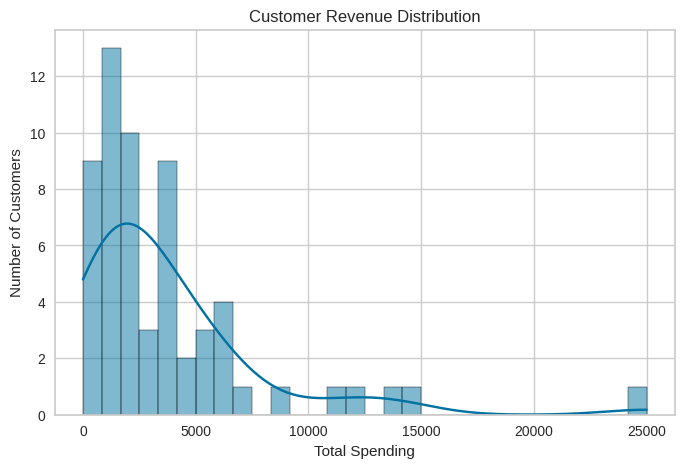

In [27]:
# Visualize the distribution of customer revenue using a histogram with a KDE curve.
# This helps identify spending patterns and the spread of customer value.

plt.figure(figsize=(8,5))

sns.histplot(
    Final_data['total_spending'],
    bins=30,
    kde=True
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

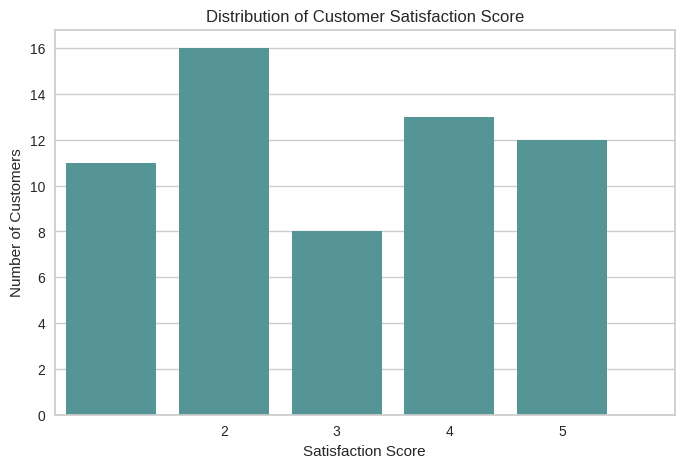

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=Final_data,
    x='satisfaction_score',
    color='#4C9F9F'
)

plt.title("Distribution of Customer Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.xticks(sorted(Final_data['satisfaction_score'].unique()))

plt.show()

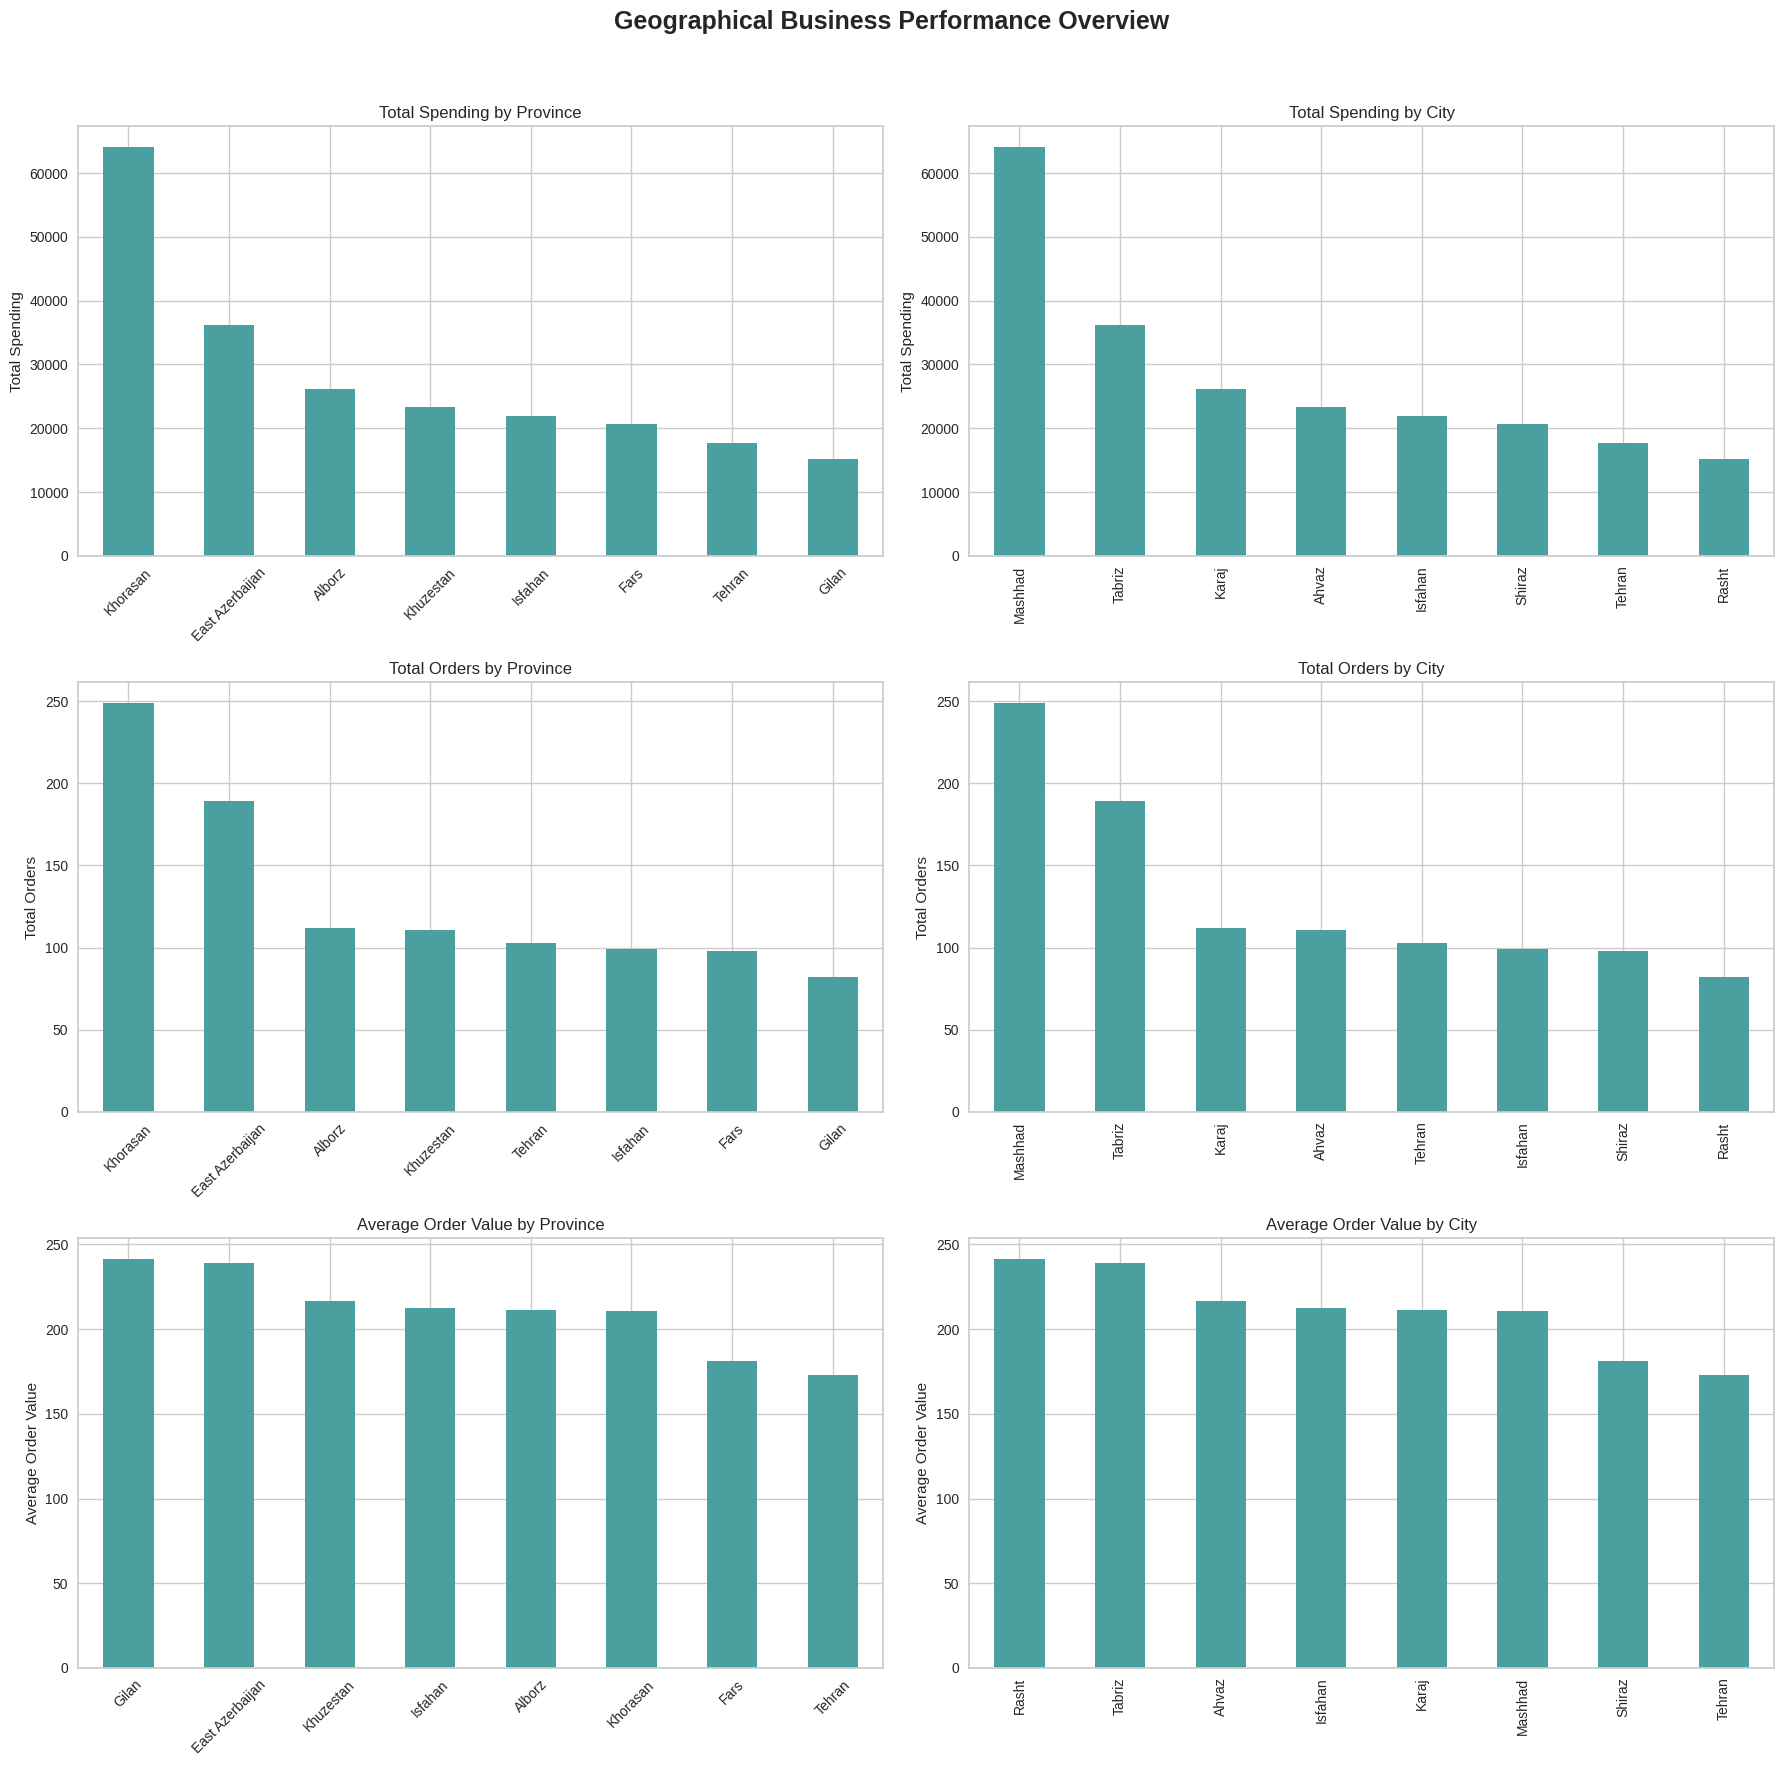

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

color = '#4C9F9F'

# 1. Total Spending by Province
province_spending = Final_data.groupby('province')['total_spending'].sum().sort_values(ascending=False)

province_spending.plot(kind='bar', ax=axes[0,0], color=color)
axes[0,0].set_title("Total Spending by Province")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Total Spending")
axes[0,0].tick_params(axis='x', rotation=45)


# 2. Total Spending by City
city_spending = Final_data.groupby('city')['total_spending'].sum().sort_values(ascending=False)

city_spending.plot(kind='bar', ax=axes[0,1], color=color)
axes[0,1].set_title("Total Spending by City")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Total Spending")
axes[0,1].tick_params(axis='x', rotation=90)


# 3. Total Orders by Province
province_orders = Final_data.groupby('province')['purchase_count'].sum().sort_values(ascending=False)

province_orders.plot(kind='bar', ax=axes[1,0], color=color)
axes[1,0].set_title("Total Orders by Province")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Total Orders")
axes[1,0].tick_params(axis='x', rotation=45)


# 4. Total Orders by City
city_orders = Final_data.groupby('city')['purchase_count'].sum().sort_values(ascending=False)

city_orders.plot(kind='bar', ax=axes[1,1], color=color)
axes[1,1].set_title("Total Orders by City")
axes[1,1].set_xlabel("")
axes[1,1].set_ylabel("Total Orders")
axes[1,1].tick_params(axis='x', rotation=90)


# 5. Average Order Value by Province
province_aov = Final_data.groupby('province')['avg_order_value'].mean().sort_values(ascending=False)

province_aov.plot(kind='bar', ax=axes[2,0], color=color)
axes[2,0].set_title("Average Order Value by Province")
axes[2,0].set_xlabel("")
axes[2,0].set_ylabel("Average Order Value")
axes[2,0].tick_params(axis='x', rotation=45)


# 6. Average Order Value by City
city_aov = Final_data.groupby('city')['avg_order_value'].mean().sort_values(ascending=False)

city_aov.plot(kind='bar', ax=axes[2,1], color=color)
axes[2,1].set_title("Average Order Value by City")
axes[2,1].set_xlabel("")
axes[2,1].set_ylabel("Average Order Value")
axes[2,1].tick_params(axis='x', rotation=90)


fig.suptitle("Geographical Business Performance Overview",
             fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3️⃣ ⭐ Customer Value Analysis

Identified the **Top 10 most valuable customers** based on purchasing behavior to support loyalty campaign decisions.

---

In [30]:
# Identify the top 10 customers based on their total spending to support customer value analysis and loyalty targeting.

top_10_customers = Final_data.sort_values(
    by='total_spending',
    ascending=False
).head(10)

top_10_customers

,customer_id,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
29,1030,M,60.00,Mashhad,Khorasan,VIP,26,156.89,25000.00,340,Cash,Web,Yes,4,4,2025,3
43,1044,M,64.00,Shiraz,Fars,Gold,33,434.98,14354.34,165,Card,Android,No,7,2,2024,7
56,1057,M,58.00,Ahvaz,Khuzestan,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4,2024,6
11,1012,F,51.00,Mashhad,Khorasan,Gold,27,434.50,11731.50,224,Online Wallet,iPhone,Yes,3,2,2023,7
8,1009,M,61.00,Karaj,Alborz,Silver,34,341.63,11615.42,232,Card,Web,No,8,2,2021,5
58,1059,F,57.00,Isfahan,Isfahan,Gold,31,287.05,8898.55,224,Online Wallet,iPhone,Yes,0,5,2023,9
9,1010,F,45.37,Karaj,Alborz,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1,2022,6
49,1050,F,48.00,Mashhad,Khorasan,Bronze,30,206.60,6198.00,205,Cash,Android,Yes,2,2,2023,8
3,1004,F,58.00,Mashhad,Khorasan,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,2021,11
54,1055,M,62.00,Rasht,Gilan,Bronze,19,319.38,6068.22,221,Online Wallet,iPhone,No,0,1,2024,2


### 4️⃣ ⚠️ Churn Risk Analysis

Identified customers with reduced purchasing activity who may require retention strategies.

---

In [31]:
# Identify customers at risk of churn based on the highest values of days since their last purchase.
# Customers with longer inactivity periods are considered potential churn risks.

churn_threshold = Final_data['last_purchase_days'].quantile(0.75)

at_risk_customers = Final_data[
    Final_data['last_purchase_days'] >= churn_threshold
].sort_values(
    by='last_purchase_days',
    ascending=False
)

at_risk_customers.head(10)

,customer_id,gender,age,city,province,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month
34,1035,M,58.00,Tabriz,East Azerbaijan,Bronze,17,348.13,5918.21,365,Cash,Android,No,5,3,2022,5
48,1049,F,32.00,Mashhad,Khorasan,Gold,23,93.06,2140.38,357,Card,Web,No,1,1,2023,1
41,1042,F,43.00,Ahvaz,Khuzestan,Gold,12,48.06,576.72,350,Online Wallet,Android,Yes,5,5,2021,12
29,1030,M,60.00,Mashhad,Khorasan,VIP,26,156.89,25000.00,340,Cash,Web,Yes,4,4,2025,3
57,1058,F,47.00,Tehran,Tehran,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,No,0,2,2024,9
15,1016,F,45.00,Shiraz,Fars,Bronze,11,136.17,1497.87,333,Online Wallet,Android,Yes,3,2,2024,9
52,1053,M,32.00,Tehran,Tehran,Gold,18,322.53,5805.54,320,Online Wallet,Web,Yes,6,1,2021,11
28,1029,F,34.00,Tabriz,East Azerbaijan,Gold,2,323.32,646.64,319,Cash,Web,Yes,4,5,2023,7
18,1019,M,22.00,Shiraz,Fars,Bronze,4,308.72,1234.88,317,Card,iPhone,No,4,2,2021,10
24,1025,F,41.00,Mashhad,Khorasan,VIP,2,406.03,812.06,317,Online Wallet,Android,Yes,2,2,2021,6


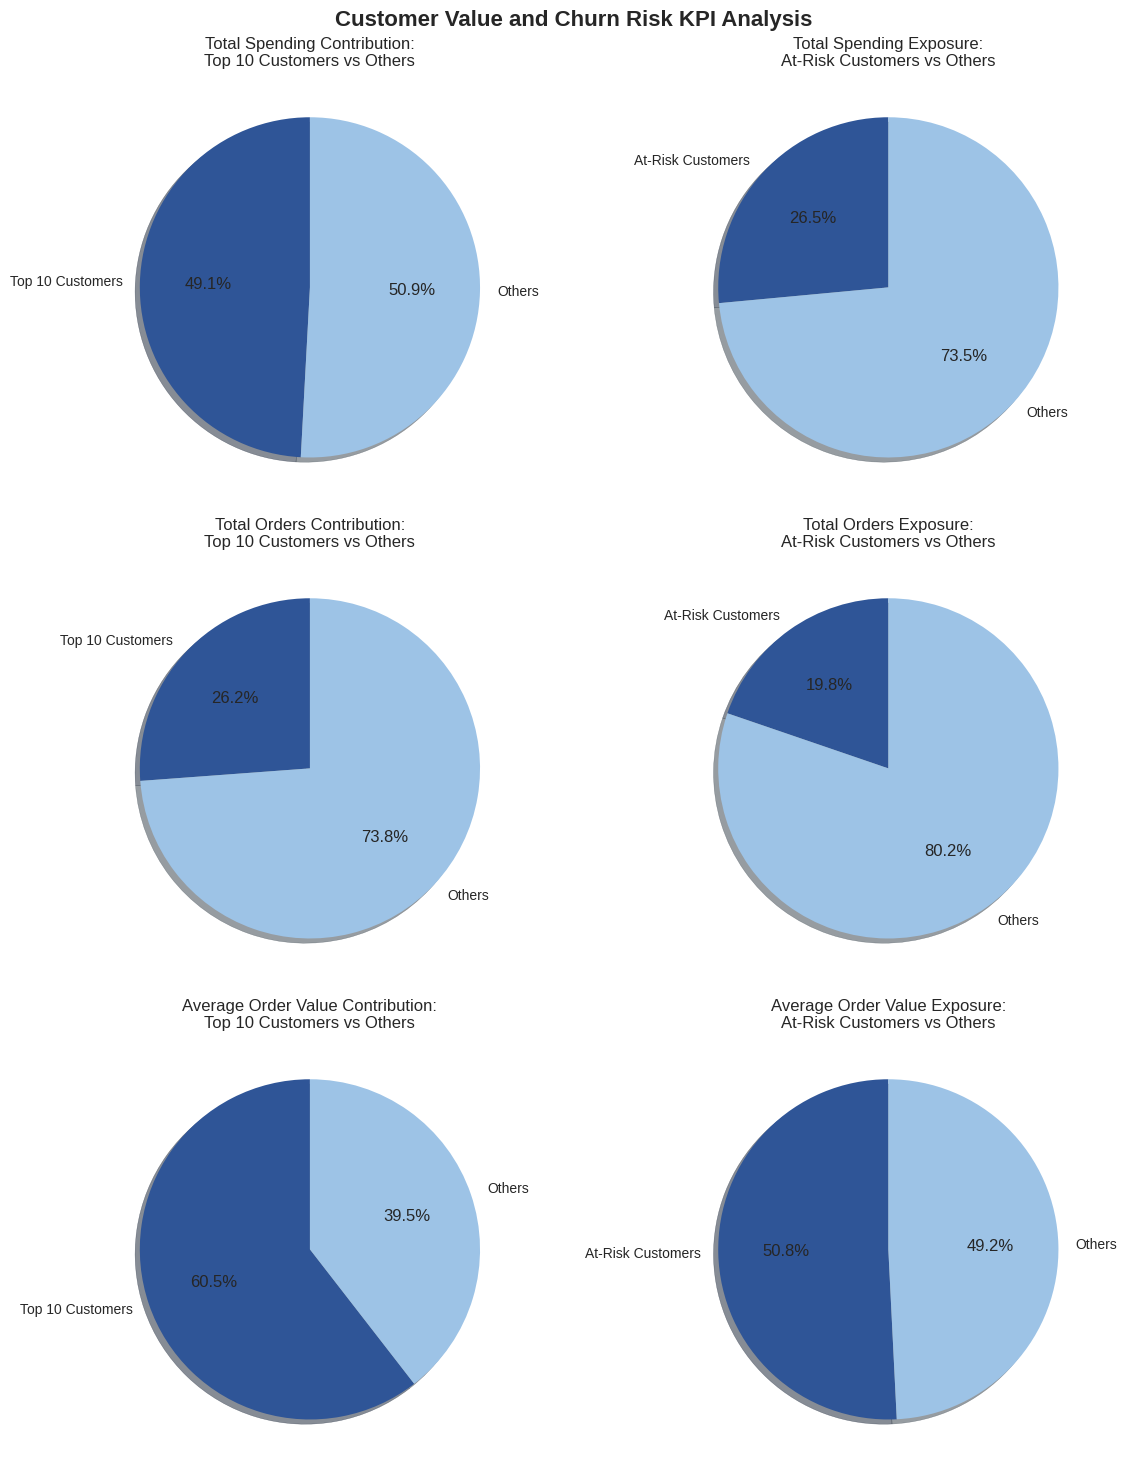

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

kpis = [
    ('total_spending', 'Total Spending'),
    ('purchase_count', 'Total Orders'),
    ('avg_order_value', 'Average Order Value')
]


for i, (kpi, title) in enumerate(kpis):

    # --- Top 10 Customers Contribution ---
    
    top10_value = top_10_customers[kpi].sum() if kpi != 'avg_order_value' else top_10_customers[kpi].mean()
    
    others_value = (
        Final_data[kpi].sum() - top10_value
        if kpi != 'avg_order_value'
        else Final_data[kpi].mean()
    )

    top10_colors = ['#2F5597', '#9DC3E6']  # dark blue, light blue
    risk_colors = ['#2F5597', '#9DC3E6']

    top10_data = pd.Series({
        'Top 10 Customers': top10_value,
        'Others': others_value
    })

    axes[i, 0].pie(
    top10_data,
    labels=top10_data.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=top10_colors
)
    
    

    axes[i, 0].set_title(
        f"{title} Contribution:\nTop 10 Customers vs Others"
    )


    # --- At-Risk Customers Contribution ---

    risk_value = at_risk_customers[kpi].sum() if kpi != 'avg_order_value' else at_risk_customers[kpi].mean()

    active_value = (
        Final_data[kpi].sum() - risk_value
        if kpi != 'avg_order_value'
        else Final_data[kpi].mean()
    )

    risk_data = pd.Series({
        'At-Risk Customers': risk_value,
        'Others': active_value
    })
    
    axes[i, 1].pie(
    risk_data,
    labels=risk_data.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=risk_colors
)

  
    axes[i, 1].set_title(
        f"{title} Exposure:\nAt-Risk Customers vs Others"
    )


plt.suptitle(
    "Customer Value and Churn Risk KPI Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 5️⃣ 🏷️ Discount Analysis

Compared purchasing behavior between:

- Customers who used discounts
- Customers who did not use discounts

---

In [33]:
# Compare customer purchasing behavior based on discount usage.
# Calculate the average total spending, purchase frequency,
#and average order value for customers who used discounts versus those who did not.

discount_comparison = Final_data.groupby('discount_used').agg({
    'total_spending': 'mean',
    'purchase_count': 'mean',
    'avg_order_value': 'mean'
}).reset_index()

discount_comparison

,discount_used,total_spending,purchase_count,avg_order_value
0,No,3736.74,17.29,220.70
1,Yes,3782.05,17.50,203.29


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Discount Usage Analysis Insight</h3>

<p>
The impact of discount usage was evaluated by comparing key customer behavior metrics, 
including <b>total spending</b>, <b>purchase frequency</b>, and 
<b>average order value</b> between customers who used discounts and those who did not.
</p>

<p>
This analysis helps determine whether discounts effectively encourage customer 
engagement and increase purchasing activity. By comparing these KPIs, we can assess 
whether discount strategies contribute to higher customer value or mainly reduce 
revenue without generating significant additional purchases.
</p>

<p>
The results provide valuable insights for optimizing promotional strategies and 
help identify whether discounts should be used as a customer acquisition tool, 
a retention strategy, or applied more selectively to maximize business value.
</p>

</div>

### 6️⃣ 📈 Pareto Analysis

Analyzed revenue distribution to determine whether a small percentage of customers generates most of the company's revenue.

In [34]:
# Select customer ID and revenue-related metric
pareto_data = Final_data[['customer_id', 'total_spending']].copy()

# Rank customers based on total spending
pareto_data = pareto_data.sort_values(
    by='total_spending',
    ascending=False
).reset_index(drop=True)

pareto_data.head()

,customer_id,total_spending
0,1030,25000.00
1,1044,14354.34
2,1057,13532.74
3,1012,11731.50
4,1009,11615.42


In [35]:
# Calculate total revenue across all customers
total_revenue = pareto_data['total_spending'].sum()

# Calculate each customer's percentage contribution to total revenue
pareto_data['revenue_percentage'] = (
    pareto_data['total_spending'] / total_revenue
) * 100

# Calculate cumulative revenue contribution for Pareto analysis
pareto_data['cumulative_percentage'] = (
    pareto_data['revenue_percentage'].cumsum()
)

pareto_data.head()

,customer_id,total_spending,revenue_percentage,cumulative_percentage
0,1030,25000.00,11.09,11.09
1,1044,14354.34,6.37,17.46
2,1057,13532.74,6.00,23.47
3,1012,11731.50,5.21,28.67
4,1009,11615.42,5.15,33.82


In [36]:
# Calculate total revenue generated by all customers
total_revenue = pareto_data['total_spending'].sum()

# Calculate each customer's contribution to total revenue (%)
pareto_data['revenue_percentage'] = (
    pareto_data['total_spending'] / total_revenue
) * 100

# Calculate cumulative revenue contribution (%) for Pareto analysis
pareto_data['cumulative_percentage'] = (
    pareto_data['revenue_percentage'].cumsum()
)

pareto_data.head()

,customer_id,total_spending,revenue_percentage,cumulative_percentage
0,1030,25000.00,11.09,11.09
1,1044,14354.34,6.37,17.46
2,1057,13532.74,6.00,23.47
3,1012,11731.50,5.21,28.67
4,1009,11615.42,5.15,33.82


In [37]:
# Find the first customer reaching or exceeding 80% cumulative revenue
customers_80 = pareto_data[
    pareto_data['cumulative_percentage'] >= 80
].index[0]

# Calculate percentage of customers contributing to 80% of revenue
percentage_customers = (
    (customers_80 + 1) / len(pareto_data)
) * 100

# Display Pareto insight
print(
    f"{percentage_customers:.2f}% of customers generate approximately 80% of revenue")

45.00% of customers generate approximately 80% of revenue


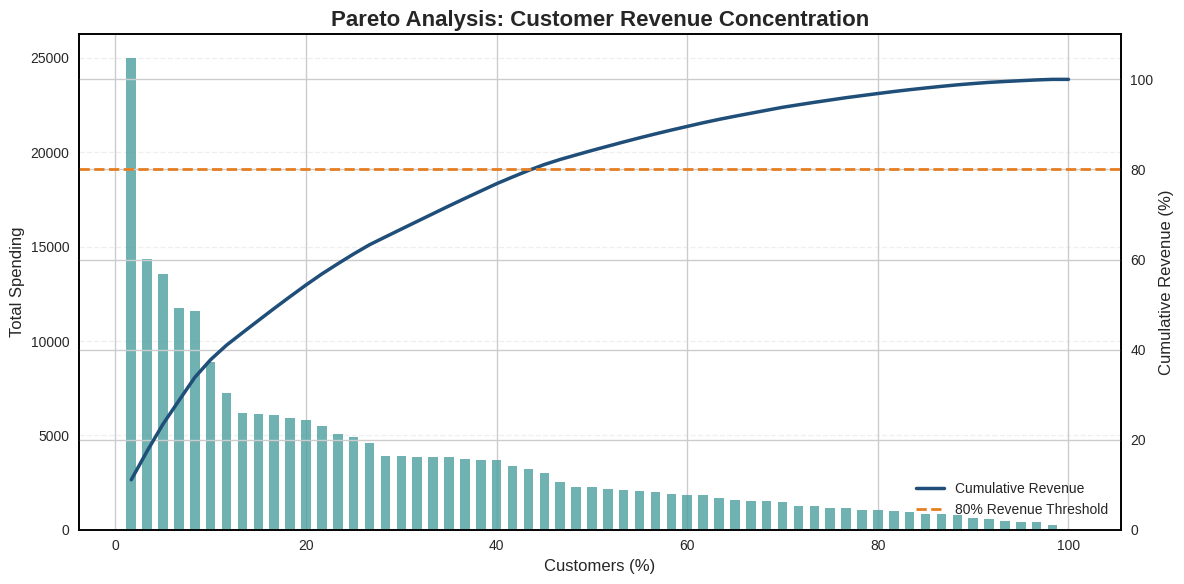

In [38]:
import matplotlib.pyplot as plt

# Calculate cumulative percentage of customers
pareto_data['customer_percentage'] = (
    (pareto_data.index + 1) / len(pareto_data)
) * 100


fig, ax1 = plt.subplots(figsize=(12, 6))

# Revenue contribution bars
ax1.bar(
    pareto_data['customer_percentage'],
    pareto_data['total_spending'],
    color='#4C9F9F',
    alpha=0.8,
    width=1
)

ax1.set_xlabel(
    "Customers (%)",
    fontsize=12
)

ax1.set_ylabel(
    "Total Spending",
    fontsize=12
)


# Cumulative revenue line
ax2 = ax1.twinx()

ax2.plot(
    pareto_data['customer_percentage'],
    pareto_data['cumulative_percentage'],
    color='#1F4E79',
    linewidth=2.5,
    label='Cumulative Revenue'
)


# 80% revenue threshold
ax2.axhline(
    y=80,
    color='#E67E22',
    linestyle='--',
    linewidth=2,
    label='80% Revenue Threshold'
)


ax2.set_ylabel(
    "Cumulative Revenue (%)",
    fontsize=12
)

ax2.set_ylim(0, 110)


# Title
plt.title(
    "Pareto Analysis: Customer Revenue Concentration",
    fontsize=16,
    fontweight='bold'
)


# Add black axis lines
for spine in ax1.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)


ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


ax2.legend(
    loc='lower right',
    shadow=True
)


plt.tight_layout()
plt.show()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Pareto Analysis Insight</h3>

<p>
The Pareto analysis shows that revenue is concentrated among a relatively small group of customers. 
Approximately 45% of customers generate 80% of total revenue, indicating that a limited number of high-value customers contribute significantly to business performance.
</p>

<p>
These customers should be prioritized through retention strategies, loyalty programs, and personalized offers to maintain their contribution and maximize customer lifetime value.
</p>

</div>

### 2️⃣ 👥 Customer Segmentation

 Customers were segmented using **RFM Analysis**:

 - 🔄 **Recency:** How recently customers purchased
 - 🔁 **Frequency:** How often customers purchased
 - 💵 **Monetary:** How much customers spent

 K-Means clustering was applied to identify meaningful customer groups.

---


In [41]:
 #Create a customer information dataset by removing RFM-related behavioral features.
 #Keep only customer profile attributes for further demographic and segmentation analysis.

customer_information = Final_data.drop(
    ['purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days'],
    axis=1
)
customer_information.set_index('customer_id', inplace=True)
customer_information.shape

(60, 12)

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    RFM Methodology
</div>

In [42]:
# Create the RFM dataset by extracting Recency (R), Frequency (F), and Monetary (M) values for each customer.

RFM = pd.DataFrame({
    'customer_id': Final_data['customer_id'],
    'R':Final_data['last_purchase_days'],
    'F':Final_data['purchase_count'],
    'M':Final_data['total_spending'],
})
RFM.set_index('customer_id', inplace=True)
RFM.head()

,R,F,M
customer_id,,,
1001,16,17,2066.01
1002,3,12,3917.64
1003,22,21,1248.66
1004,40,23,6121.45
1005,273,23,3899.42


In [43]:
#profile_RFM = ProfileReport(RFM, title="RFM data EDA", type_schema = {"Ed": "categorical", "Default": "categorical"})

#profile_RFM.to_file("RFM_dataset_profile_report.html")

---

## 📈 Exploratory Data Analysis (EDA) on Aggregated RFM Data

After aggregating customer-level data, exploratory data analysis (EDA) was performed to evaluate data quality and understand the distribution of the main RFM metrics.

The distributions of **Recency (R)**, **Frequency (F)**, **Monetary (M)**, were analyzed to identify customer behavior patterns, detect potential outliers, and prepare the features for customer segmentation.

---

## 🎛️ RFM Categorization and Scoring

To transform continuous RFM values into meaningful customer behavior scores, each metric was categorized into five groups based on customer activity levels.

### 🔹 Recency (R)
Recency represents the number of days since the customer's last purchase. Lower values indicate more recent customer activity.

Categories:

- 0 ≤ R < 60
- 60 ≤ R < 120
- 120 ≤ R < 180
- 180 ≤ R < 240
- R ≥ 240

### 🔹 Frequency (F)
Frequency represents the total number of purchases made by each customer. Higher values indicate more engaged customers.

Categories:

- 0 ≤ F < 10
- 10 ≤ F < 17
- 17 ≤ F < 27
- 27 ≤ F < 35
- F ≥ 35

### 🔹 Monetary (M)
Monetary represents the total spending amount of each customer. Higher monetary values indicate higher customer value.

Categories:

- 0 ≤ M < 1200
- 1200 ≤ M < 2100
- 2100 ≤ M < 3900
- 3900 ≤ M < 5000
- M ≥ 5000

In [44]:
# Convert Recency, Frequency, and Monetary values into categorical scores using predefined bins.
# Recency is scored inversely because recent purchases indicate higher customer engagement,
# while Frequency and Monetary are scored positively based on higher customer activity and value.
# Remove the original RFM variables after generating the score-based features.

bins_dict = {
    'R': [0, 60, 120, 180, 240, float('inf')],
    'F': [0, 10, 17, 27, 35, float('inf')],
    'M': [0, 1200, 2100, 3900, 5000, float('inf')],
}

for col in ['R', 'F', 'M']:
    if col == 'R':
        RFM[f'{col}_Score'] = pd.cut(RFM[col], bins=bins_dict[col], labels=[5, 4, 3, 2, 1], right=False)
    else:
        RFM[f'{col}_Score'] = pd.cut(RFM[col], bins=bins_dict[col], labels=[1, 2, 3, 4, 5], right=False)

RFM.drop(columns=['R', 'F', 'M'], inplace=True)

RFM.head()

,R_Score,F_Score,M_Score
customer_id,,,
1001,5,3,2
1002,5,2,4
1003,5,3,2
1004,5,3,5
1005,1,3,3


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Fitting K-Means Model
</div>

In [45]:
# Apply K-Means clustering on RFM scores and evaluate different numbers of clusters.
# Calculate WCSS (within-cluster sum of squares) for the Elbow Method and silhouette scores
# to determine the optimal number of customer segments.

X = RFM[['R_Score','F_Score','M_Score']]

cluster_range = range(2, 7)  

# List to store WCSS values
wss = []
silhouette_scores = []

# Calculate WCSS for each cluster number
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init='auto', max_iter=100,
                    tol=0.0001, random_state=880, algorithm='lloyd')
    kmeans.fit(X)
    wss.append(kmeans.inertia_)
    labels = kmeans.predict(X)
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)

In [46]:
# Create a summary table comparing clustering performance metrics for different numbers of clusters.
# This table is used to evaluate the optimal number of clusters based on WCSS and silhouette score values.

cluster_metrics = pd.DataFrame({
    'Number of Clusters': list(cluster_range),
    'WCSS': wss,
    'Silhouette Score': silhouette_scores
})

cluster_metrics

,Number of Clusters,WCSS,Silhouette Score
0,2,185.58,0.37
1,3,131.45,0.35
2,4,101.36,0.35
3,5,80.52,0.37
4,6,66.63,0.40


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    RFM Visualization
</div>

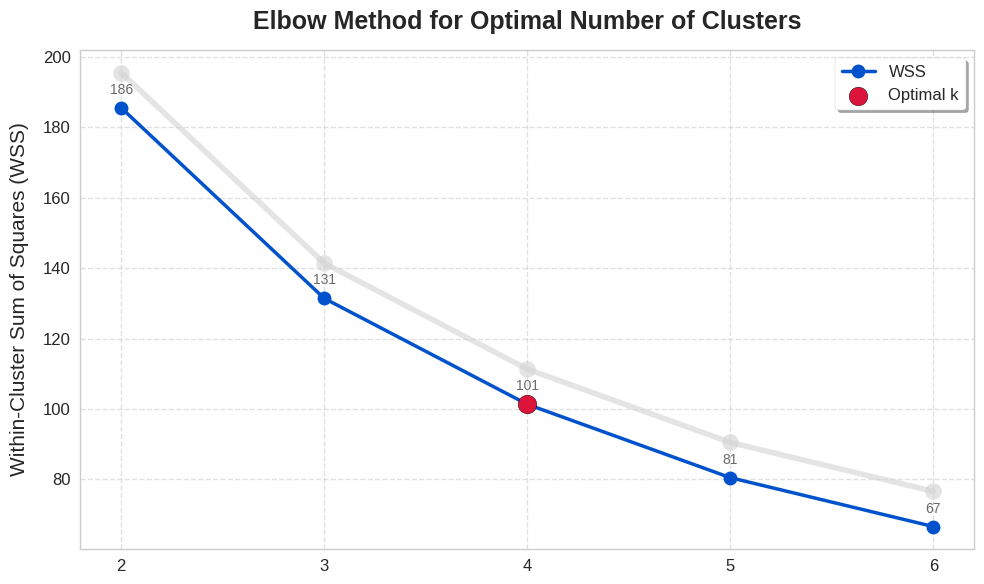

In [47]:
# Visualize the Elbow Method to determine the optimal number of clusters based on WSS values.
# The selected k value is highlighted to show the chosen number of customer segments.

plt.style.use('seaborn-v0_8-whitegrid')

k_opt = 4  

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cluster_range, [w + 10 for w in wss], 
        marker='o', markersize=12, linewidth=4, color='lightgray', alpha=0.6, zorder=1)

ax.plot(cluster_range, wss, marker='o', markersize=10, linewidth=2.5, color='#0052cc', zorder=2, label='WSS')

ax.scatter(k_opt, wss[cluster_range.index(k_opt)], 
           color='crimson', s=180, edgecolor='black', zorder=3, label='Optimal k')

ax.set_title('Elbow Method for Optimal Number of Clusters', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Within-Cluster Sum of Squares (WSS)', fontsize=15, labelpad=10)

for i, txt in enumerate(wss):
    ax.annotate(f"{txt:.0f}", (cluster_range[i], wss[i]), 
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='dimgray')

ax.set_xticks(cluster_range)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

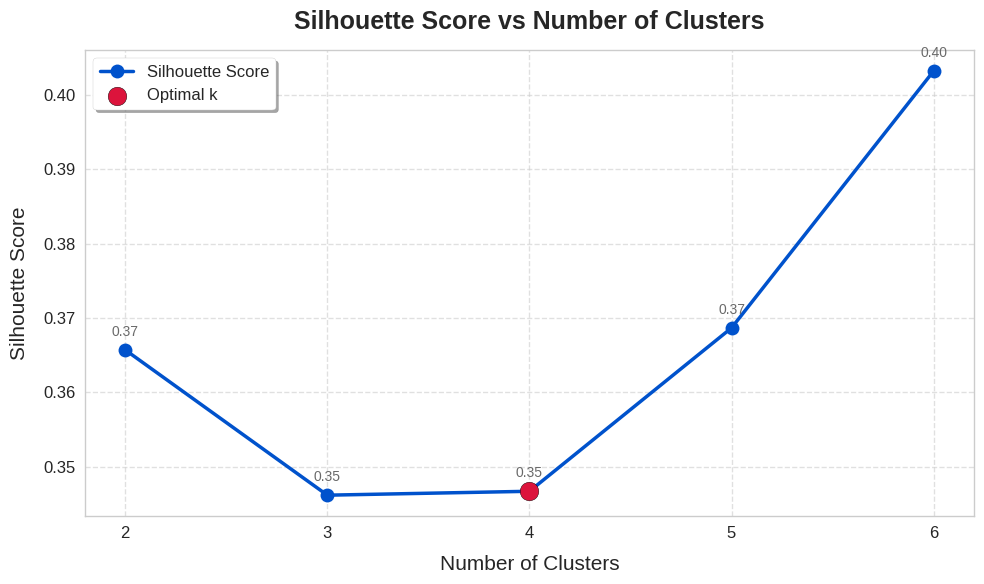

In [48]:
# Visualize silhouette scores for different numbers of clusters to evaluate clustering quality.
# The selected optimal k value is highlighted based on the highest silhouette score.

plt.style.use('seaborn-v0_8-whitegrid')

k_opt = 4

fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(cluster_range, silhouette_scores, marker='o', markersize=10, linewidth=2.5, 
        color='#0052cc', zorder=2, label='Silhouette Score')

ax.scatter(k_opt, silhouette_scores[cluster_range.index(k_opt)],
           color='crimson', s=180, edgecolor='black', zorder=3, label='Optimal k')

ax.set_title('Silhouette Score vs Number of Clusters', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Number of Clusters', fontsize=15, labelpad=10)
ax.set_ylabel('Silhouette Score', fontsize=15, labelpad=10)

for i, txt in enumerate(silhouette_scores):
    ax.annotate(f"{txt:.2f}", (cluster_range[i], silhouette_scores[i]),
                textcoords="offset points", xytext=(0, 10), ha='center',
                fontsize=10, color='dimgray')

ax.set_xticks(cluster_range)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Optimal Number of Clusters Selection</h3>

<p>
The optimal number of customer segments was evaluated using two clustering evaluation 
metrics: <b>Within-Cluster Sum of Squares (WSS)</b> and the <b>Silhouette Score</b>.
</p>

<p>
The Elbow Method based on WSS shows a noticeable improvement up to 
<b>four clusters</b>, after which the reduction in within-cluster variation becomes 
less significant. Additionally, the Silhouette Score indicates that four clusters 
provide a suitable balance between cluster cohesion and separation.
</p>

<p>
Therefore, considering both evaluation metrics, <b>k = 4</b> was selected as the 
optimal number of clusters for customer segmentation. This choice allows the model 
to identify meaningful customer groups while maintaining clear differences between 
segments.
</p>

</div>

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Best Model
</div>

In [49]:
# Initialize the KMeans model
km_model = KMeans(n_clusters=4, init='k-means++', n_init='auto', max_iter=300,
                  tol=0.0001, random_state=880, algorithm='lloyd')

# Fit the model
km_model.fit(X)

# Predict the cluster labels
labels = km_model.predict(X)

# Compute the silhouette score
silhouette_avg = silhouette_score(X, labels)
silhouette = silhouette_samples(X, labels)

print(f'Silhouette Score: {silhouette_avg}')

X_kmeans = X.copy()
X_kmeans['Cluster'] = labels+1
X_kmeans['Silhouette'] = silhouette

X_kmeans.head()

Silhouette Score: 0.3467058013668414


,R_Score,F_Score,M_Score,Cluster,Silhouette
customer_id,,,,,
1001,5,3,2,2,0.29
1002,5,2,4,2,-0.01
1003,5,3,2,2,0.29
1004,5,3,5,1,0.29
1005,1,3,3,4,0.24


In [50]:
# Evaluate the final K-Means clustering model by retrieving the WSS value and cluster centers.
# The WSS value measures the compactness of clusters,
# while cluster centers represent the average profile of each customer segment.

wss = km_model.inertia_
print(f"WSS: {wss:.2f}")

print("-"*80)

centers = km_model.cluster_centers_
print("Cluster Centers:\n", centers)

WSS: 101.36
--------------------------------------------------------------------------------
Cluster Centers:
 [[3.4        3.8        3.8       ]
 [4.         1.86666667 1.93333333]
 [1.38888889 1.72222222 1.5       ]
 [1.41176471 3.23529412 4.29411765]]


In [51]:
# Suppress warnings
warnings.filterwarnings("ignore")

# Define the score column names

X_kmeans['Cluster'] = X_kmeans['Cluster']
clusters = sorted(X_kmeans['Cluster'].unique())

# Ensure the score columns are of float type
scores = ['R_Score', 'F_Score', 'M_Score']
X_kmeans[scores] = X_kmeans[scores].astype(float)

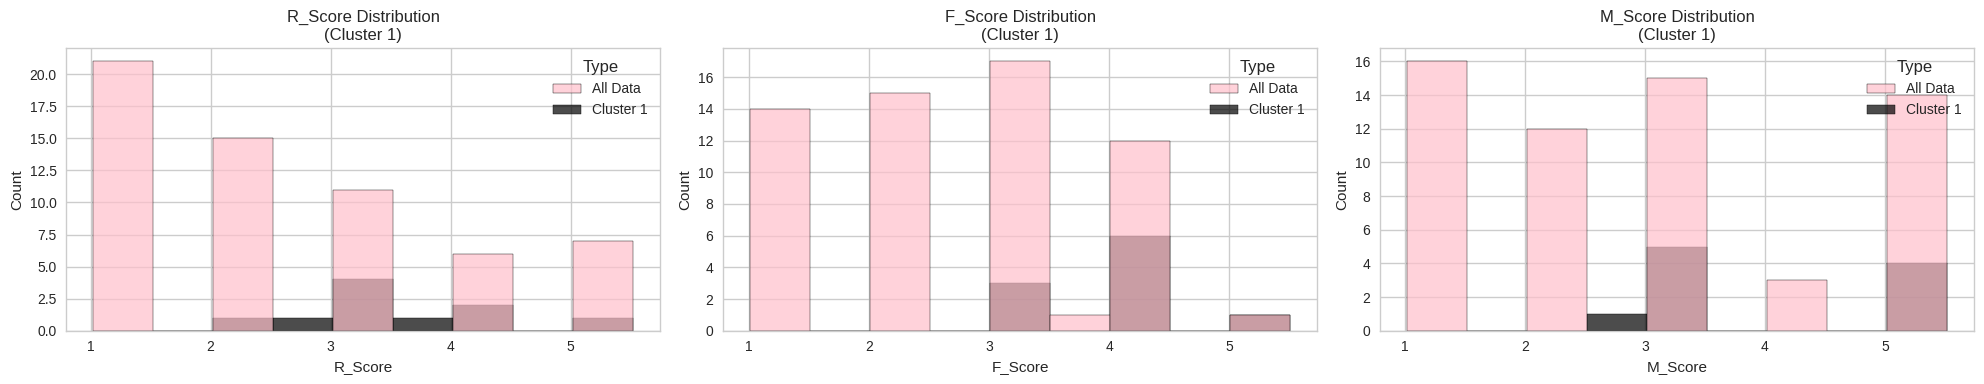

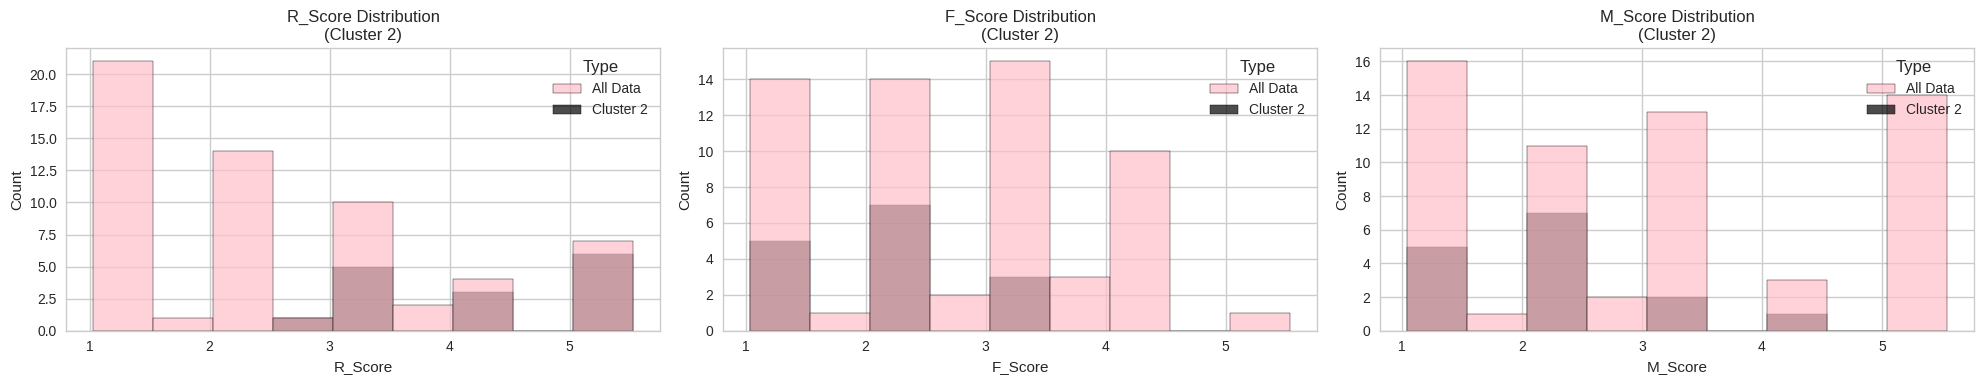

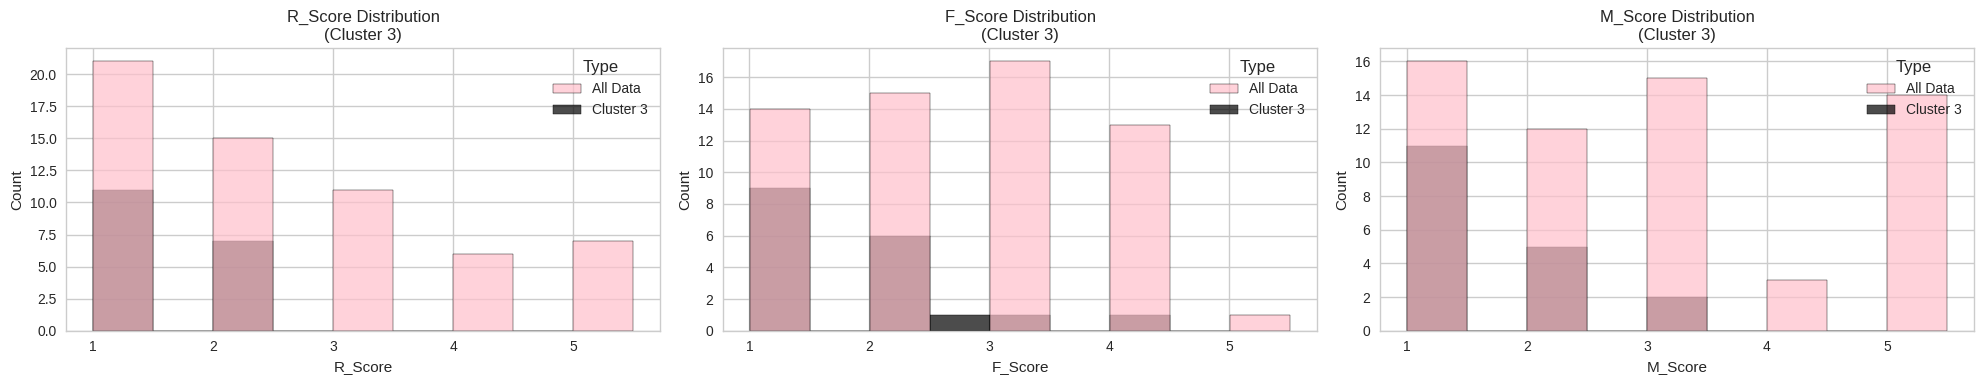

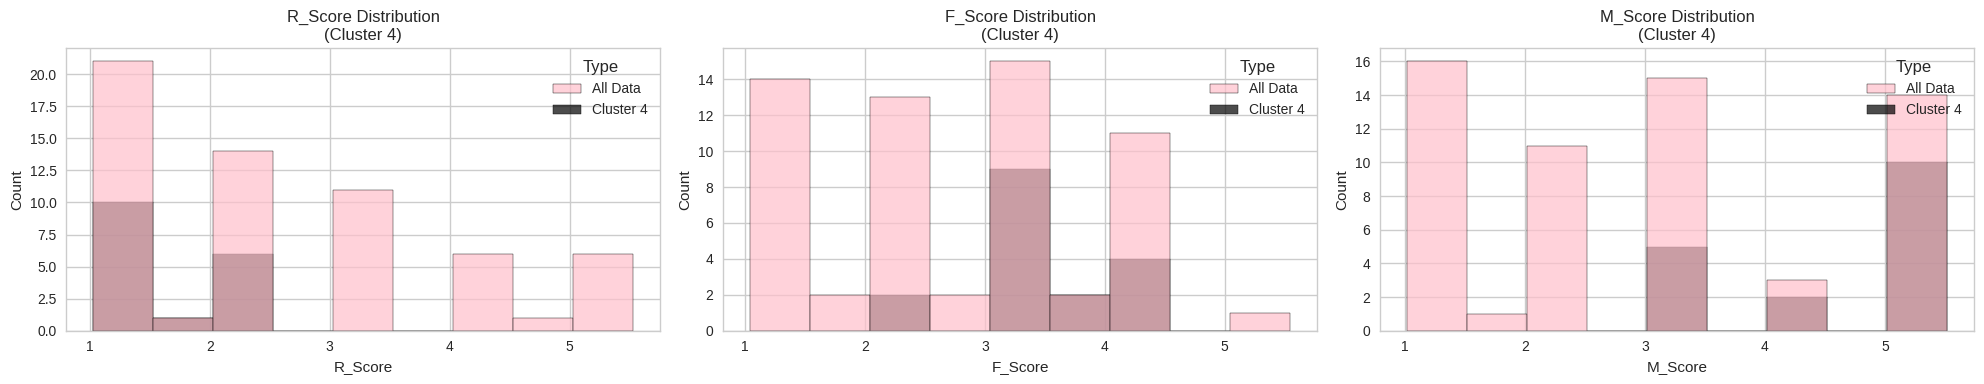

In [52]:
# Loop through each cluster
for cluster in clusters:
    # Create subplots: one for each score
    fig, axes = plt.subplots(1, len(scores), figsize=(20, 4))
    
    for i, score in enumerate(scores):
        ax = axes[i]

        # Create DataFrame for all data and for the specific cluster
        all_data = pd.DataFrame({score: X_kmeans[score], 'Type': 'All Data'})
        data_cluster = pd.DataFrame({
            score: X_kmeans.loc[X_kmeans['Cluster'] == cluster, score],
            'Type': f'Cluster {cluster}'
        })
        # Combine both DataFrames for plotting
        data_combined = pd.concat([all_data, data_cluster])

        # Add half-unit jitter to the score for better visualization
        data_combined[score+'_float'] = data_combined[score] + np.random.uniform(0, 0.5, len(data_combined))

        # Define bins with 0.5 spacing
        bins = np.arange(data_combined[score+'_float'].min(),
                         data_combined[score+'_float'].max() + 0.5,
                         0.5)

        # Plot histogram with hue for cluster vs all data
        sns.histplot(
            x=score+'_float',
            hue='Type',
            data=data_combined,
            ax=ax,
            palette=['pink', 'black'],
            bins=bins,
            stat='count',
            alpha=0.7
        )

        # Set title and axis labels
        ax.set_title(f'{score} Distribution\n(Cluster {cluster})')
        ax.set_xlabel(score)
        ax.set_ylabel('Count')

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

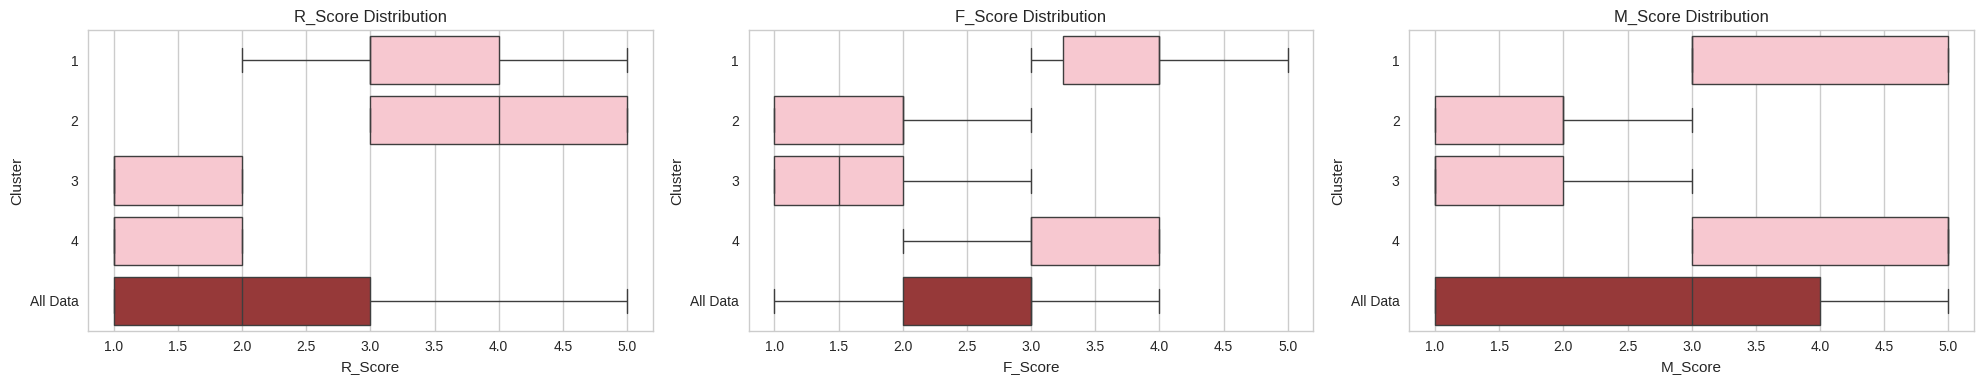

In [56]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, len(scores), figsize=(20, 4))

# Define the colors
pink_color = 'pink'  
dark_pink_color = 'brown'  

# Loop over each score and create a horizontal box plot
for i, score in enumerate(scores):
    ax = axes[i]    
    
    # Create a DataFrame for all data
    df_all_data = X_kmeans[[score]].copy()
    df_all_data['Cluster'] = 'All Data'

    # Combine the all data DataFrame with the original DataFrame
    combined_df = pd.concat([X_kmeans[['Cluster', score]], df_all_data], ignore_index=True)

    # Sort the clusters including 'All Data'
    combined_df['Cluster'] = pd.Categorical(combined_df['Cluster'], categories= clusters + ['All Data'], ordered=True)

    # Create a horizontal box plot
    sns.boxplot(y='Cluster', x=score, data=combined_df, palette= [pink_color] * len(clusters) + [dark_pink_color], ax=ax, showfliers=False)

    # Set the title and labels
    ax.set_title(f'{score} Distribution')
    ax.set_xlabel(score)
    ax.set_ylabel('Cluster')

plt.tight_layout()
plt.show()

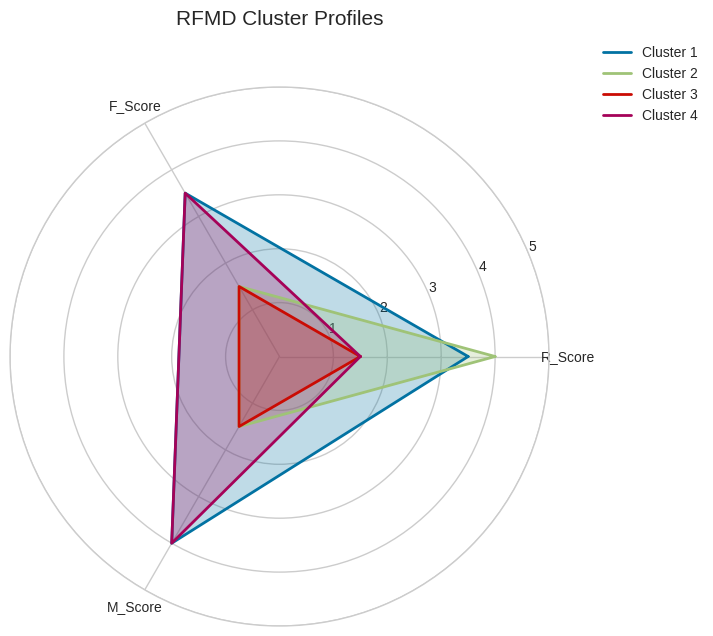

In [57]:
# Visualize customer segment characteristics using a radar chart.
# The chart compares the average Recency, Frequency, and Monetary scores across clusters
# to highlight differences in customer behavior profiles.

radar_data = pd.DataFrame({
    'Cluster': [1, 2, 3, 4],
    'R_Score': [3.5, 4,1.5, 1.5],     
    'F_Score': [3.5, 1.5, 1.5, 3.5],      
    'M_Score': [4, 1.5, 1.5, 4],            
})

cluster_profiles = radar_data.groupby('Cluster').mean()

labels = cluster_profiles.columns

num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cluster in cluster_profiles.index:
    values = cluster_profiles.loc[cluster].tolist()
    values += values[:1]  # بستن حلقه
    ax.plot(angles, values, linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'])
plt.title("RFMD Cluster Profiles", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Customer Segment Insights</h3>

<p>
The K-Means clustering approach identified four distinct customer segments based on 
their <b>Recency (R)</b>, <b>Frequency (F)</b>, and <b>Monetary (M)</b> behaviors. 
Each segment represents a different level of customer engagement and requires a 
specific business strategy.
</p>

<h4 style="color:#6fa8dc;">Cluster 1: Loyal &amp; High-Value Customers</h4>

<p>
This segment includes customers with relatively high values across all RFM metrics. 
They have relatively recent activity, purchase frequently, and generate high monetary 
value. These customers represent one of the most valuable segments for the business. 
Retention strategies such as loyalty programs, exclusive offers, personalized 
communication, and rewards can help maintain their engagement and strengthen 
long-term customer relationships.
</p>

<h4 style="color:#6fa8dc;">Cluster 2: Fresh Customers</h4>

<p>
This group has high recency, indicating relatively recent activity, but low frequency 
and monetary scores. These customers have interacted with the business recently but 
have not yet developed strong purchasing habits or generated substantial revenue. 
They represent an important growth opportunity. Targeted onboarding campaigns, 
personalized recommendations, introductory offers, and incentives for repeat purchases 
can encourage them to become more frequent and valuable customers.
</p>

<h4 style="color:#6fa8dc;">Cluster 3: Churn Customers</h4>

<p>
Customers in this segment have low scores across all RFM dimensions. They have not 
purchased recently, purchase infrequently, and generate relatively low monetary value. 
This indicates weak engagement and a higher risk of losing these customers. 
Cost-effective re-engagement campaigns, personalized reminders, and targeted 
incentives can be used to encourage them to return and determine whether they can 
be reactivated.
</p>

<h4 style="color:#6fa8dc;">Cluster 4: At-Risk High-Value Customers</h4>

<p>
This segment is particularly important because customers have low recency but 
relatively high frequency and monetary scores. Although they have not purchased 
recently, their purchasing history indicates that they were frequent and high-value 
customers. They may therefore represent customers who are at risk of churn rather 
than consistently low-value customers. Priority should be given to win-back campaigns, 
personalized offers, exclusive incentives, and direct communication to encourage 
them to return.
</p>

<p>
Overall, the segmentation provides actionable insights by distinguishing between 
loyal high-value customers, growth opportunities, low-value customers, and previously 
valuable customers at risk of churn. This enables the business to allocate marketing 
resources more effectively and design strategies tailored to customer retention, 
development, and reactivation.
</p>

</div>


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Cluster Summary Table
</div>

In [59]:
# ---------------------------
# 1. Calculate cluster means
# ---------------------------
cluster_summary = X_kmeans.groupby('Cluster').mean().reset_index()

# Rename columns for Customer
cluster_summary = X_kmeans.groupby('Cluster')[
    ['R_Score', 'F_Score', 'M_Score']
].mean().reset_index()

# ---------------------------
# 2. Calculate counts and percentages
# ---------------------------
cluster_counts = X_kmeans['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'count']
cluster_counts['percentage'] = (cluster_counts['count'] / len(X_kmeans)) * 100

# Merge counts with summary
cluster_summary = pd.merge(cluster_summary, cluster_counts, on='Cluster')

# ---------------------------
# 3. Calculate overall mean
# ---------------------------
overall_mean = X_kmeans[['R_Score', 'F_Score', 'M_Score']].mean().to_frame().T
overall_mean['Cluster'] = 'All Data'
overall_mean['count'] = len(X_kmeans)
overall_mean['percentage'] = 100.0

# Append overall mean
cluster_summary = pd.concat([cluster_summary, overall_mean], ignore_index=True)

# ---------------------------
# 4. Replace cluster codes with names
# ---------------------------
cluster_name = {
    '1': 'Loyal Customers',
    '2': 'Fresh Customers',
    '3': 'Churn Customers',
    '4': 'At-Risk High-Value Customers'
}

# Only replace numeric clusters
cluster_summary['Cluster'] = cluster_summary['Cluster'].astype(str).replace(cluster_name)

# ---------------------------
# 5. View final summary
# ---------------------------
cluster_summary

,Cluster,R_Score,F_Score,M_Score,count,percentage
0,Loyal Customers,3.40,3.80,3.80,10,16.67
1,Fresh Customers,4.00,1.87,1.93,15,25.00
2,Churn Customers,1.39,1.72,1.50,18,30.00
3,At-Risk High-Value Customers,1.41,3.24,4.29,17,28.33
4,All Data,2.38,2.53,2.78,60,100.00


In [60]:
# Create a binary feature to identify VIP customers based on their assigned cluster.
# Remove clustering-related features after extracting the VIP indicator.
# Merge customer demographic information with the VIP customer label to create the final customer dataset.
# Save the resulting dataset as a CSV file for further analysis or reporting.

X_kmeans['Loyal_customer'] = (X_kmeans['Cluster'] == 4).astype(int)
X_kmeans = X_kmeans.drop(columns=['R_Score','F_Score','M_Score','Cluster','Silhouette'])
merged_data = pd.merge(customer_information, X_kmeans, on="customer_id", how="inner")
merged_data.to_csv('Customer.csv')

In [61]:
# Load the final customer dataset

Customer = pd.read_csv("/kaggle/working/Customer.csv")
Customer.set_index('customer_id', inplace=True)
Customer.head()

,gender,age,city,province,membership_tier,payment_method,device,discount_used,returned_items,satisfaction_score,signup_year,signup_month,Loyal_customer
customer_id,,,,,,,,,,,,,
1001,F,19.00,Karaj,Alborz,VIP,Card,Android,Yes,3,5,2025,2,0
1002,M,53.00,Tehran,Tehran,Gold,Card,Web,No,5,3,2022,8,0
1003,F,31.00,Shiraz,Fars,Gold,Online Wallet,iPhone,Yes,6,1,2023,6,0
1004,F,58.00,Mashhad,Khorasan,Gold,Card,Android,No,4,4,2021,11,0
1005,M,28.00,Isfahan,Isfahan,Silver,Online Wallet,Android,Yes,7,4,2021,10,1


In [63]:
# Convert the continuous age variable into meaningful age categories for customer profiling.
# Remove the original age column after creating the categorical age feature.

Customer['age_category'] = pd.cut(
    Customer['age'],
    bins=[18, 35, 50, 65],
    labels=['Young Adult', 'Adult', 'Senior']
)

Customer.drop(columns=['age'], inplace=True)

Customer.shape

(60, 13)

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Statistical Analysis
</div>

In [65]:
# Calculate expected frequencies for Chi-square tests between customer attributes and VIP status.
# Check the proportion of cells with low expected counts(<5) to evaluate whether the Chi-square test assumptions are satisfied.
# Store and display expected frequency tables for each categorical feature to support statistical analysis.

expected_values_dict = {}
low_expected_percentage_dict = {}

for col in Customer.columns:
    
    if col == 'Loyal_customer':
        continue

    contingency = pd.crosstab(Customer[col], Customer['Loyal_customer'])
    _, _, _, exp = chi2_contingency(contingency)

    exp_df = pd.DataFrame(
        exp,
        index=contingency.index,
        columns=contingency.columns
    )
    
    expected_values_dict[col] = exp_df

    percentage_low_expected = (
        (exp < 5).sum().sum() / (exp.shape[0] * exp.shape[1]) * 100
    )

    low_expected_percentage_dict[col] = percentage_low_expected


for col, df_exp in expected_values_dict.items():
    print(f"📊 Expected frequencies for {col}:")
    print(df_exp.round(2))
    print(f"{col}: Percentage of cells with expected counts < 5: {low_expected_percentage_dict[col]:.2f}%")
    print("-" * 60)

📊 Expected frequencies for gender:
Loyal_customer     0    1
gender                   
F              25.08 9.92
M              17.92 7.08
gender: Percentage of cells with expected counts < 5: 0.00%
------------------------------------------------------------
📊 Expected frequencies for city:
Loyal_customer    0    1
city                    
Ahvaz          5.73 2.27
Isfahan        3.58 1.42
Karaj          5.02 1.98
Mashhad        7.88 3.12
Rasht          3.58 1.42
Shiraz         4.30 1.70
Tabriz         8.60 3.40
Tehran         4.30 1.70
city: Percentage of cells with expected counts < 5: 75.00%
------------------------------------------------------------
📊 Expected frequencies for province:
Loyal_customer     0    1
province                 
Alborz          5.02 1.98
East Azerbaijan 8.60 3.40
Fars            4.30 1.70
Gilan           3.58 1.42
Isfahan         3.58 1.42
Khorasan        7.88 3.12
Khuzestan       5.73 2.27
Tehran          4.30 1.70
province: Percentage of cells with expec

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Chi-Square Test Assumption Evaluation</h3>

<p>
The expected frequency analysis was performed to evaluate whether the categorical 
variables meet the assumptions required for applying the Chi-square test when 
examining their relationship with <b>Loyal Customer</b> status.
</p>

<p>
The results indicate that <b>gender</b>, <b>payment method</b>, <b>device</b>, 
<b>discount usage</b>, and <b>age category</b> have no expected cells below 5. 
This indicates that the expected-frequency assumption is fully satisfied for 
these variables, making them suitable for the standard Chi-square test.
</p>

<p>
However, several features show a high percentage of cells with expected counts below 
5. In particular, <b>city</b>, <b>province</b>, and <b>returned_items</b> have 
<b>75%</b>, <b>75%</b>, and <b>77.78%</b> of cells below the recommended threshold, 
respectively. <b>signup_month</b> shows the highest proportion, with 
<b>83.33%</b> of cells having expected counts below 5. These results indicate that 
these variables contain many categories with relatively few observations, which may 
reduce the reliability of the standard Chi-square test.
</p>

<p>
Other variables show partial violations of the expected-frequency assumption. 
<b>Membership tier</b> has <b>25%</b> of cells below 5, while 
<b>satisfaction score</b> and <b>signup_year</b> have <b>50%</b> and 
<b>60%</b>, respectively. Therefore, the Chi-square results for these variables 
should be interpreted with greater caution.
</p>

<p>
Overall, the results suggest that the Chi-square test assumptions are well satisfied 
for <b>gender, payment method, device, discount usage, and age category</b>. For 
variables with many low expected frequencies, particularly <b>city, province, 
returned_items, and signup_month</b>, combining sparse categories or using an 
alternative statistical approach may improve the robustness and reliability of 
the analysis.
</p>

</div>


In [67]:
# Calculate residuals for each categorical feature to compare observed and expected frequencies.
# Positive residuals indicate that the observed count is higher than expected,
# while negative residuals indicate fewer observations than expected.
# These residuals help identify categories that contribute more strongly to the association with VIP status.

residuals_dict = {}

for col in Customer.columns:
    
    if col == 'Loyal_customer':
        continue

    contingency = pd.crosstab(Customer[col], Customer['Loyal_customer'])

    _, _, _, exp = chi2_contingency(contingency)

    exp_df = pd.DataFrame(
        exp,
        index=contingency.index,
        columns=contingency.columns
    )

    residuals = contingency - exp_df
    residuals_dict[col] = residuals

    print(f"\nColumn: {col}")
    print("📈 Residuals (Observed - Expected):")
    print(residuals.round(2))
    print("-" * 60)


Column: gender
📈 Residuals (Observed - Expected):
Loyal_customer     0     1
gender                    
F               0.92 -0.92
M              -0.92  0.92
------------------------------------------------------------

Column: city
📈 Residuals (Observed - Expected):
Loyal_customer     0     1
city                      
Ahvaz           2.27 -2.27
Isfahan        -1.58  1.58
Karaj          -1.02  1.02
Mashhad        -0.88  0.88
Rasht          -0.58  0.58
Shiraz          1.70 -1.70
Tabriz         -0.60  0.60
Tehran          0.70 -0.70
------------------------------------------------------------

Column: province
📈 Residuals (Observed - Expected):
Loyal_customer      0     1
province                   
Alborz          -1.02  1.02
East Azerbaijan -0.60  0.60
Fars             1.70 -1.70
Gilan           -0.58  0.58
Isfahan         -1.58  1.58
Khorasan        -0.88  0.88
Khuzestan        2.27 -2.27
Tehran           0.70 -0.70
------------------------------------------------------------

Colum

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Loyal Customer Residual Analysis</h3>

<p>
The residual analysis was conducted to identify which categories contribute most to 
the difference between the observed and expected frequencies of <b>Loyal Customer</b> 
status. Positive residuals for loyal customers indicate more loyal customers than 
expected, while negative residuals indicate fewer loyal customers than expected.
</p>

<p>
For <b>gender</b>, female customers show a slightly higher number of loyal customers 
than expected, while male customers show slightly fewer. However, the residuals are 
small (<b>±0.92</b>), suggesting only a weak difference between the two groups.
</p>

<p>
The strongest differences appear across <b>city</b> and <b>province</b>. In the city 
analysis, <b>Ahvaz</b> has the largest positive residual for non-loyal customers 
(<b>+2.27</b>) and a corresponding negative residual for loyal customers 
(<b>-2.27</b>), indicating fewer loyal customers than expected. In contrast, 
<b>Shiraz</b> shows more non-loyal customers than expected, while <b>Isfahan</b> 
shows relatively more loyal customers than expected. Similar patterns are observed 
at the province level, with <b>Khuzestan</b> showing fewer loyal customers than 
expected and <b>Fars</b> and <b>Isfahan</b> showing relatively more loyal customers.
</p>

<p>
For <b>membership tier</b>, the <b>Silver</b> group shows the largest residual 
(<b>+1.73</b>) for loyal customers, indicating more loyal customers than expected. 
In contrast, Bronze customers show fewer loyal customers than expected. The Gold and 
VIP groups have relatively small residuals, suggesting that their observed loyalty 
levels are close to what would be expected.
</p>

<p>
Regarding <b>payment method</b>, customers using an <b>Online Wallet</b> show more 
loyal customers than expected, with a residual of <b>+1.48</b>. Card users show 
fewer loyal customers than expected. However, the magnitude of these residuals 
remains relatively moderate.
</p>

<p>
For <b>device usage</b>, Android users show more loyal customers than expected 
(<b>+1.77</b>), whereas Web users show fewer loyal customers than expected 
(<b>-1.67</b>). iPhone users have almost no deviation from the expected frequency, 
with a residual close to zero.
</p>

<p>
The residuals for <b>discount usage</b> are very small (<b>±0.37</b>), indicating 
that the observed number of loyal customers among customers who used or did not use 
discounts is very close to the expected frequency.
</p>

<p>
For <b>returned items</b>, all residuals are relatively small, with the largest 
deviation being below <b>1.0</b>. This suggests that no particular return-count 
category shows a strong deviation from the expected number of loyal customers.
</p>

<p>
For <b>satisfaction score</b>, the residuals are also relatively small. The largest 
positive residual for loyal customers occurs at satisfaction score <b>1</b> 
(<b>+0.88</b>), while score 3 shows a negative deviation. Overall, there is no 
strong residual pattern across satisfaction levels.
</p>

<p>
For <b>signup year</b>, customers who joined in <b>2023</b> show more loyal customers 
than expected (<b>+1.73</b>), while customers who joined in <b>2022</b> show fewer 
loyal customers than expected (<b>-1.25</b>). The 2021, 2024, and 2025 groups show 
smaller deviations from their expected frequencies.
</p>

<p>
The residuals for <b>signup month</b> are generally small, with the largest positive 
residual for loyal customers occurring in <b>June</b> (<b>+1.27</b>). This suggests 
that no individual signup month shows a particularly strong deviation from the 
expected loyalty pattern.
</p>

<p>
Finally, <b>age category</b> shows very small residuals across all groups. Young 
Adults have slightly more loyal customers than expected, while Adults have slightly 
fewer. The Senior group is almost identical to its expected frequency.
</p>

<p>
Overall, the largest deviations from expected loyalty levels are observed in 
<b>city, province, membership tier, device, and signup year</b>. In contrast, 
<b>gender, discount usage, returned items, satisfaction score, signup month, and age 
category</b> show relatively small residuals. These residual patterns provide useful 
direction for identifying potentially important customer characteristics, although 
statistical significance should ultimately be evaluated using the corresponding 
Chi-square test results and p-values.
</p>

</div>


In [68]:
def OR_CIs(contingency_table):
    
    # Calculate odds ratio
    odds_ratio = (contingency_table.iloc[0, 0] / contingency_table.iloc[0, 1]) / (contingency_table.iloc[1, 0] / contingency_table.iloc[1, 1])

    # Calculate standard error of log(odds ratio)
    log_odds_std_error = np.sqrt(contingency_table.applymap(lambda x: 1/x).sum().sum())

    # Set confidence level
    confidence_level = 0.95

    # Calculate z-score for the confidence interval
    z_score = norm.ppf(1-(1 - confidence_level) / 2)

    # Calculate confidence intervals
    ci_low = np.exp(np.log(odds_ratio) - z_score * log_odds_std_error)
    ci_high = np.exp(np.log(odds_ratio) + z_score * log_odds_std_error)

    # Print the results
    print(f"Odds Ratio: {odds_ratio:.2f}")
    print(f"95% Confidence Interval: {ci_low:.2f}, {ci_high:.2f}")
    
    return odds_ratio, (ci_low, ci_high)

In [71]:
odds_ratios_dict = {}

for col in Customer.columns:
    if col == 'Loyal_customer':
        continue
        
    contingency = pd.crosstab(Customer[col], Customer['Loyal_customer'])
    
    if contingency.shape == (2, 2):
        odds_ratio = (contingency.iloc[0, 0] / contingency.iloc[0, 1]) / (contingency.iloc[1, 0] / contingency.iloc[1, 1])
        odds_ratios_dict[col] = odds_ratio
        print(f"nColumn: {col}")
        OR_CIs(contingency)

nColumn: gender
Odds Ratio: 1.36
95% Confidence Interval: 0.44, 4.22
nColumn: discount_used
Odds Ratio: 0.88
95% Confidence Interval: 0.28, 2.76


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Odds Ratio Analysis</h3>

<p>
The odds ratio analysis was conducted to examine whether <b>gender</b> and 
<b>discount usage</b> are associated with the likelihood of being classified as a 
<b>Loyal Customer</b>.
</p>

<p>
For <b>gender</b>, the odds ratio is <b>1.36</b>, indicating that the group coded as 
the exposure has approximately <b>36% higher odds</b> of being a loyal customer 
compared with the reference group. However, the <b>95% confidence interval 
(0.44–4.22)</b> includes 1, indicating that this observed difference is not 
statistically significant.
</p>

<p>
For <b>discount usage</b>, the odds ratio is <b>0.88</b>, suggesting that customers 
who used discounts have approximately <b>12% lower odds</b> of being loyal compared 
with the reference group. However, the <b>95% confidence interval (0.28–2.76)</b> 
also includes 1, indicating that this association is not statistically significant.
</p>

<p>
Overall, neither <b>gender</b> nor <b>discount usage</b> provides statistically 
significant evidence of an association with customer loyalty. Although the estimated 
odds ratios suggest differences between the groups, the wide confidence intervals 
indicate substantial uncertainty around these estimates.
</p>

</div>

In [73]:
for col in Customer.columns:
    if col == 'Loyal_customer':
        continue
        
    contingency = pd.crosstab(Customer[col], Customer['Loyal_customer'])
    row_percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100

    chi2, p, dof,_ = chi2_contingency(contingency)
    print(f"\nChi-Square for {col}: p-value={p:.4f}")
    if p > 0.05:
        print(f"👉 {col} is not significantly associated with VIP status.")
    else:
        print(f"👉 {col} is significantly associated with VIP status.")
    
    print("\nContingency Table (Counts):")
    print(contingency)
    print("\nRow Percentages (%):")
    print(row_percentages.round(2))
    print("Degrees of freedom:", dof)
    print("Expected frequencies:\n", exp)
    print("-"*60)


Chi-Square for gender: p-value=0.8087
👉 gender is not significantly associated with VIP status.

Contingency Table (Counts):
Loyal_customer   0  1
gender               
F               26  9
M               17  8

Row Percentages (%):
Loyal_customer     0     1
gender                    
F              74.29 25.71
M              68.00 32.00
Degrees of freedom: 1
Expected frequencies:
 [[13.61666667  5.38333333]
 [14.33333333  5.66666667]
 [15.05        5.95      ]]
------------------------------------------------------------

Chi-Square for city: p-value=0.1905
👉 city is not significantly associated with VIP status.

Contingency Table (Counts):
Loyal_customer  0  1
city                
Ahvaz           8  0
Isfahan         2  3
Karaj           4  3
Mashhad         7  4
Rasht           3  2
Shiraz          6  0
Tabriz          8  4
Tehran          5  1

Row Percentages (%):
Loyal_customer      0     1
city                       
Ahvaz          100.00  0.00
Isfahan         40.00 60.00
Ka

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Chi-Square Analysis of Loyal Customer Status</h3>

<p>
Chi-square tests were conducted to examine whether customer characteristics and 
behavioral variables are significantly associated with <b>Loyal Customer</b> status. 
Using a significance level of <b>α = 0.05</b>, none of the tested variables showed 
a statistically significant association with customer loyalty.
</p>

<p>
Among the demographic variables, <b>gender</b> was not significantly associated with 
loyalty (<b>p = 0.8087</b>). Although the proportion of loyal customers was slightly 
higher among males (<b>32.00%</b>) than females (<b>25.71%</b>), the difference is 
not statistically significant. Similarly, <b>age category</b> showed no significant 
association (<b>p = 0.9010</b>), with loyal customer rates ranging from 
<b>25.00%</b> among Adults to <b>31.58%</b> among Young Adults.
</p>

<p>
Geographic variables also showed no statistically significant relationship with 
loyalty. Neither <b>city</b> nor <b>province</b> was significantly associated with 
Loyal Customer status (<b>p = 0.1905</b> for both). Although some differences can be 
observed descriptively—for example, Isfahan had a relatively high loyal customer 
rate (<b>60.00%</b>), while Ahvaz and Shiraz had no loyal customers in this sample—
these differences are not statistically significant.
</p>

<p>
Customer-related behavioral characteristics also failed to show significant 
associations. <b>Membership tier</b> (<b>p = 0.5243</b>), <b>payment method</b> 
(<b>p = 0.6570</b>), and <b>device</b> (<b>p = 0.5002</b>) were not significantly 
related to loyalty. Online Wallet users had the highest observed loyalty rate 
(<b>34.78%</b>), compared with <b>22.22%</b> for Card users, but the difference 
was not statistically significant.
</p>

<p>
<b>Discount usage</b> showed virtually no association with loyalty 
(<b>p = 1.0000</b>). The proportion of loyal customers was <b>29.41%</b> among 
customers who did not use discounts and <b>26.92%</b> among those who used 
discounts. This suggests that discount usage does not appear to distinguish loyal 
customers in this dataset.
</p>

<p>
Similarly, <b>returned items</b> (<b>p = 0.9480</b>) and <b>satisfaction score</b> 
(<b>p = 0.9082</b>) were not significantly associated with loyalty. Although some 
individual categories show different observed loyalty rates, these differences are 
not strong enough to provide statistical evidence of an association.
</p>

<p>
Finally, neither <b>signup year</b> (<b>p = 0.6215</b>) nor <b>signup month</b> 
(<b>p = 0.6349</b>) showed a statistically significant relationship with loyalty. 
For example, customers who signed up in 2023 had a relatively high observed loyalty 
rate of <b>50.00%</b>, while those who signed up in December had a rate of 
<b>66.67%</b>. However, these percentages are based on relatively small groups and 
do not represent statistically significant differences.
</p>

<p>
Overall, the Chi-square analysis provides <b>no statistical evidence that the tested 
categorical demographic, geographic, behavioral, or temporal variables are associated 
with Loyal Customer status</b>. Therefore, customer loyalty in this dataset may be 
better explained by continuous behavioral measures such as <b>recency, purchase 
frequency, and monetary value</b>, which are directly incorporated into the RFM-based 
customer segmentation.
</p>

</div>


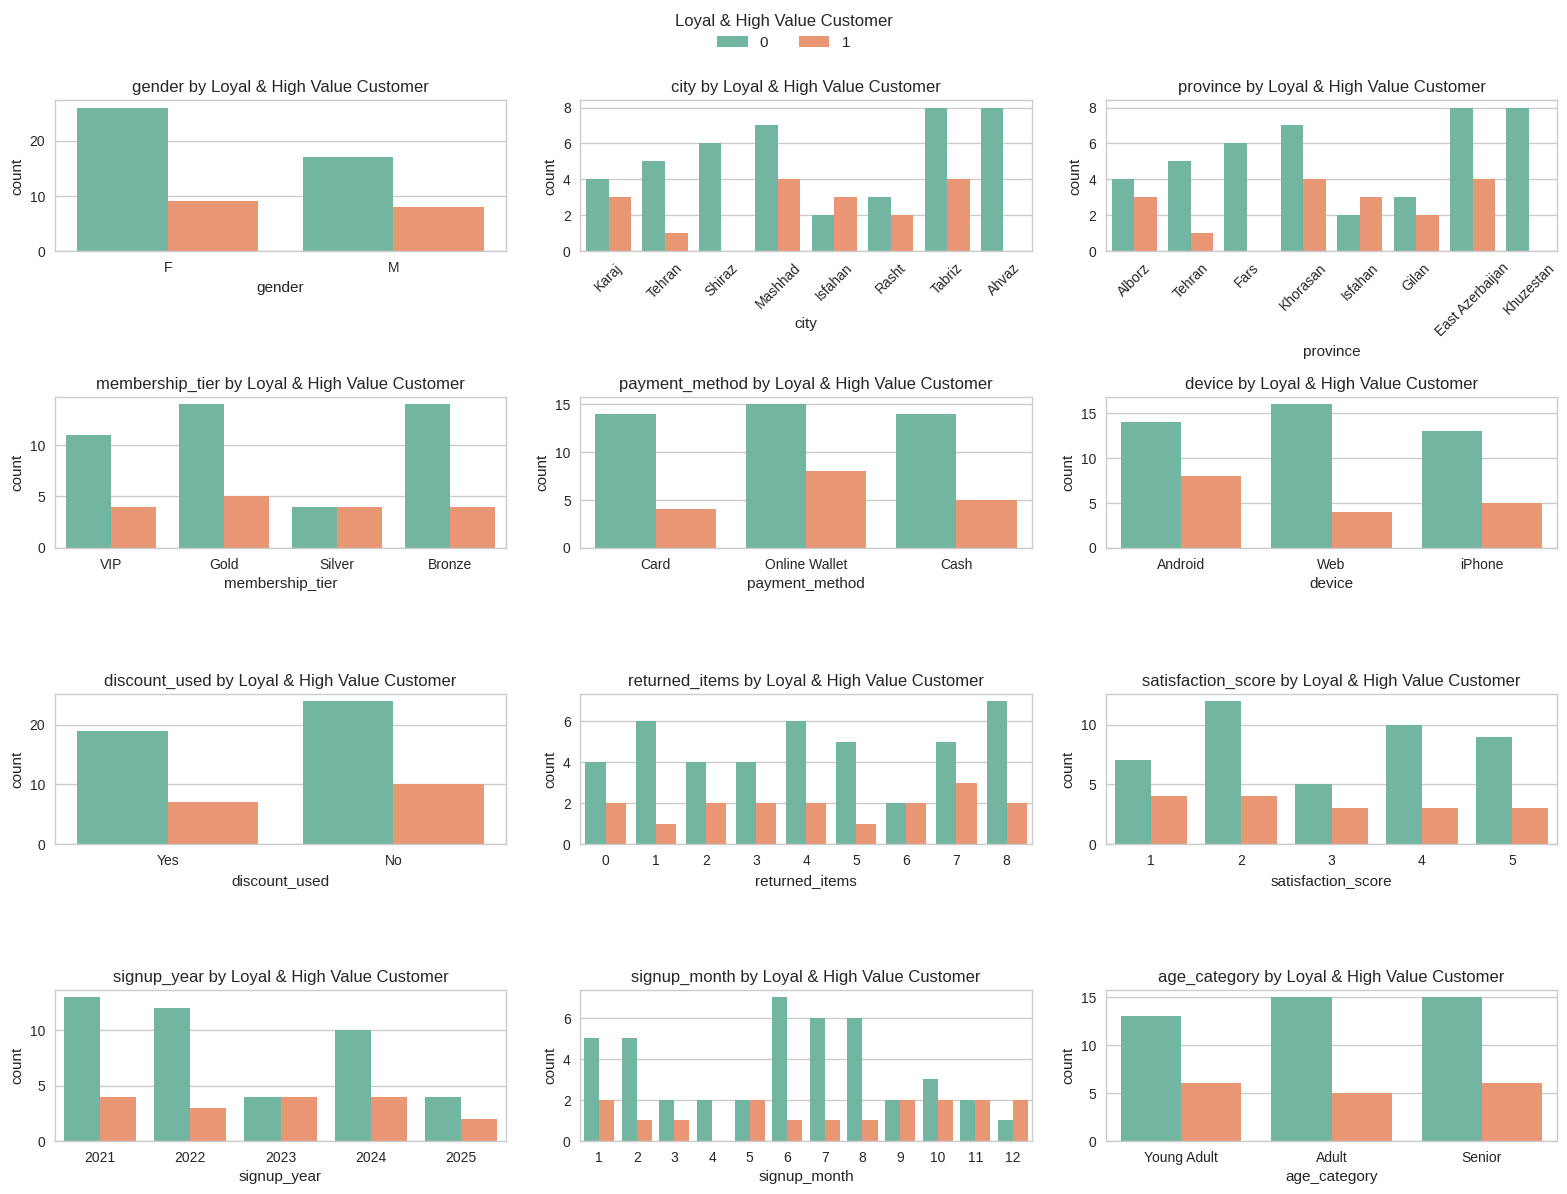

In [74]:
vip_col = "Loyal_customer"

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

plot_index = 0

for col in Customer.columns:
    
    if col == vip_col:
        continue

    ax = axes[plot_index]

    sns.countplot(
        data=Customer,
        x=col,
        hue=vip_col,
        palette="Set2",
        dodge=True,
        ax=ax
    )

    ax.set_title(f"{col} by Loyal & High Value Customer", fontsize=12)

    # Remove individual legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Rotate labels for Province and City
    if col.lower() in ["province", "city"]:
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.tick_params(axis="x", rotation=0)

    plot_index += 1


# Remove unused axes
for ax in axes[plot_index:]:
    fig.delaxes(ax)


# Add one common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Loyal & High Value Customer",
    loc="upper center",
    ncol=len(labels),
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [75]:
# Separate input features (X) and target variable (y) for the classification model.

X_Customer = Customer.drop(columns=['Loyal_customer'])
y_Customer = Customer['Loyal_customer']

In [76]:
# Define categorical feature groups for encoding.
# Apply appropriate encoding methods and combine preprocessing with the Decision Tree model in a pipeline.

ordinal = ['age_category']
nominal = [
    col for col in X_Customer.columns
    if col not in ordinal
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'nominal',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            nominal
        ),
        (
            'ordinal',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            ordinal
        )
    ],
    remainder='passthrough'
)

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=5,
            criterion='entropy',
            class_weight='balanced',
            min_samples_split=8,
            min_samples_leaf=5,
            random_state=880
        ))
    ]
)

In [77]:
# Train the complete pipeline using customer features and VIP status labels.

clf = pipeline.fit(X_Customer, y_Customer)
clf

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'city', 'province',
                                                   'membership_tier',
                                                   'payment_method', 'device',
                                                   'discount_used',
                                                   'returned_items',
                                                   'satisfaction_score',
                                                   'signup_year',
                                                   'signup_month']),
                                                 ('ordinal',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['age_category'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=5, min_samples_split=8,
                                        random_state=880))])

In [78]:
# Visualize the trained Decision Tree with feature names and class labels.
# Display the tree structure to interpret customer classification rules.

fig, ax = plt.subplots(figsize=(30, 25))

clf = pipeline.named_steps['classifier']

plot_tree(
    clf,
    feature_names=pipeline.named_steps['preprocessing'].get_feature_names_out(),
    class_names=[str(c) for c in clf.classes_],
    proportion=True,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

plt.close(fig)

In [79]:
# Transform customer features using the preprocessing pipeline and create an encoded DataFrame.

X_encoded = pd.DataFrame(
    pipeline.named_steps['preprocessing'].transform(X_Customer),
    columns=pipeline.named_steps['preprocessing'].get_feature_names_out(),
    index=X_Customer.index
)

In [80]:
# Extract and display human-readable decision rules from the trained Decision Tree.

tree_rules = export_text(
    pipeline.named_steps['classifier'],
    feature_names=list(pipeline.named_steps['preprocessing'].get_feature_names_out()),
    spacing=3,
    decimals=2,
    show_weights=True
)

print(tree_rules)

|--- nominal__province_Khuzestan <= 0.50
|   |--- nominal__province_Fars <= 0.50
|   |   |--- nominal__device_Web <= 0.50
|   |   |   |--- nominal__province_East Azerbaijan <= 0.50
|   |   |   |   |--- nominal__membership_tier_VIP <= 0.50
|   |   |   |   |   |--- weights: [5.58, 14.12] class: 1
|   |   |   |   |--- nominal__membership_tier_VIP >  0.50
|   |   |   |   |   |--- weights: [3.49, 1.76] class: 0
|   |   |   |--- nominal__province_East Azerbaijan >  0.50
|   |   |   |   |--- weights: [0.70, 7.06] class: 1
|   |   |--- nominal__device_Web >  0.50
|   |   |   |--- nominal__province_East Azerbaijan <= 0.50
|   |   |   |   |--- ordinal__age_category <= 0.50
|   |   |   |   |   |--- weights: [3.49, 0.00] class: 0
|   |   |   |   |--- ordinal__age_category >  0.50
|   |   |   |   |   |--- weights: [2.09, 7.06] class: 1
|   |   |   |--- nominal__province_East Azerbaijan >  0.50
|   |   |   |   |--- weights: [4.88, 0.00] class: 0
|   |--- nominal__province_Fars >  0.50
|   |   |--- w

In [81]:
# Define a function to extract decision rules from a trained Decision Tree.
# Traverse the tree structure and store feature-based rules with predicted classes for each leaf node.

def get_decision_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    rules = []
    
    def recurse(node, depth, rule=[]):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            rule_left = rule + [f"{name} <= {threshold:.2f}"]
            recurse(tree_.children_left[node], depth + 1, rule_left)
            rule_right = rule + [f"{name} > {threshold:.2f}"]
            recurse(tree_.children_right[node], depth + 1, rule_right)
        else:
            # Get the predicted class for the leaf node
            predicted_class = np.argmax(tree_.value[node])
            # Append the rule with the consequent
            rules.append((rule, predicted_class))
    
    recurse(0, 1)
    return rules


In [82]:
# Extract feature names from the preprocessing step and generate decision rules from the trained model.

feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

rules = get_decision_rules(clf, feature_names)

In [83]:
# Function to calculate lift, support, and confidence for each rule
def calculate_metrics_for_rule(df, rule, target_column='Target'):
    subset = df.copy()
    for condition in rule:
        if ' <= ' in condition:
            feature, value = condition.split(' <= ')
            subset = subset[subset[feature] <= float(value)]
        elif ' > ' in condition:
            feature, value = condition.split(' > ')
            subset = subset[subset[feature] > float(value)]
    
    support = len(subset) / len(df)
    if len(subset) > 0:
        confidence = len(subset[subset[target_column] == 1]) / len(subset)
    else:
        confidence = 0
    lift = confidence / (len(df[df[target_column] == 1]) / len(df))
    
    return support, confidence, lift

# Create a DataFrame to store rules, metrics, and consequents
rule_metrics = []

# Add the target variable to the encoded DataFrame
X_encoded = pd.DataFrame(X_encoded, columns=feature_names)
X_encoded['Target'] = y_Customer

for rule, consequent in rules:
    support, confidence, lift = calculate_metrics_for_rule(X_encoded, rule)
    rule_metrics.append({
        'Rule': ' AND '.join(rule),
        'Consequent': consequent,  # Add the predicted class as the consequent
        'Support': support,
        'Confidence': confidence,
        'Lift': lift
    })

# Convert the list of dictionaries into a DataFrame
rules_df = pd.DataFrame(rule_metrics)

rules_df = rules_df.reset_index(drop=True)
rules_df.insert(0, 'Row', range(1, len(rules_df) + 1))
rules_df.index = rules_df['Row']
rules_df = rules_df.drop(columns=['Row'])



# Set the maximum column width so that long rules are displayed fully
pd.set_option('display.max_colwidth', None)


rules_df = rules_df.sort_values(by='Lift', ascending=False)

rules_df = rules_df.reset_index(drop=True)
rules_df.index = rules_df.index + 1

rules_df

,Rule,Consequent,Support,Confidence,Lift
1,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars <= 0.50 AND nominal__device_Web <= 0.50 AND nominal__province_East Azerbaijan > 0.50,1,0.08,0.80,2.82
2,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars <= 0.50 AND nominal__device_Web > 0.50 AND nominal__province_East Azerbaijan <= 0.50 AND ordinal__age_category > 0.50,1,0.12,0.57,2.02
3,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars <= 0.50 AND nominal__device_Web <= 0.50 AND nominal__province_East Azerbaijan <= 0.50 AND nominal__membership_tier_VIP <= 0.50,1,0.27,0.50,1.76
4,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars <= 0.50 AND nominal__device_Web <= 0.50 AND nominal__province_East Azerbaijan <= 0.50 AND nominal__membership_tier_VIP > 0.50,0,0.10,0.17,0.59
5,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars <= 0.50 AND nominal__device_Web > 0.50 AND nominal__province_East Azerbaijan <= 0.50 AND ordinal__age_category <= 0.50,0,0.08,0.00,0.00
6,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars <= 0.50 AND nominal__device_Web > 0.50 AND nominal__province_East Azerbaijan > 0.50,0,0.12,0.00,0.00
7,nominal__province_Khuzestan <= 0.50 AND nominal__province_Fars > 0.50,0,0.10,0.00,0.00
8,nominal__province_Khuzestan > 0.50,0,0.13,0.00,0.00


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Decision Tree Rule Analysis Insight</h3>

<p style="line-height:1.6; text-align:justify;">
The Decision Tree model was used to identify customer characteristics and patterns 
associated with <b>Loyal Customer</b> status. The extracted rules provide 
interpretable combinations of demographic and behavioral characteristics that 
distinguish loyal and non-loyal customers.
</p>

<ul style="padding-left:25px;">

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Strongest Loyal Customer Pattern:</b> Customers from <b>East Azerbaijan</b>, who 
are not from Khuzestan or Fars and do not use a Web device, show the strongest 
association with loyal customer status. This rule has <b>80% confidence</b>, meaning 
that 80% of customers satisfying these conditions are classified as loyal. Its 
<b>lift of 2.82</b> indicates that this customer profile is nearly three times as 
likely to be loyal compared with the overall customer population.
</p>
</li>

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Additional Loyal Customer Pattern:</b> Customers using a <b>Web device</b> and 
belonging to the specified age category, while being outside Khuzestan, Fars, and 
East Azerbaijan, show a relatively strong association with loyalty. This rule 
achieves <b>57% confidence</b> and a <b>lift of 2.02</b>, indicating that these 
customers are approximately twice as likely to be loyal compared with the overall 
customer population.
</p>
</li>

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Broader Loyal Customer Pattern:</b> Customers who are outside Khuzestan, Fars, 
and East Azerbaijan and do not belong to the <b>VIP membership tier</b> have a 
moderate association with loyalty. This rule has the highest support among the 
positive rules at <b>27%</b>, with <b>50% confidence</b> and a <b>lift of 1.76</b>. 
This suggests that the pattern applies to a relatively larger portion of the 
customer base while still showing a higher-than-average likelihood of loyalty.
</p>
</li>

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Non-Loyal Customer Pattern:</b> Customers outside Khuzestan, Fars, and East 
Azerbaijan who belong to the <b>VIP membership tier</b> show a relatively low 
likelihood of being classified as loyal under this rule. The rule has only 
<b>17% confidence</b> and a <b>lift of 0.59</b>, indicating that loyal customers 
are underrepresented in this subgroup compared with the overall customer population.
</p>
</li>

<li>
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Business Interpretation:</b> The Decision Tree rules suggest that <b>province, 
device type, age category, and membership tier</b> contribute to the model's 
classification of loyal customers. East Azerbaijan appears in the strongest positive 
rule, while customers from Khuzestan or Fars are consistently associated with 
non-loyal outcomes in the extracted rules. However, these patterns should be 
considered <b>exploratory rather than definitive</b>, particularly because some 
rules are based on relatively small customer segments.
</p>
</li>

</ul>

</div>


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">💡 Business Recommendations</h3>

<p>
The analysis shows that <b>customer location, device type, age, and membership level</b> 
can help the company better understand differences in customer loyalty. Customers 
from some locations, particularly <b>East Azerbaijan</b>, show stronger loyalty, while 
customers from <b>Khuzestan and Fars</b> may require additional attention.
</p>

<p>
The company should develop <b>targeted loyalty campaigns</b> for customers who show 
strong engagement with the business. Personalized offers, loyalty rewards, and 
exclusive benefits can encourage these customers to continue purchasing and maintain 
long-term relationships with the company.
</p>

<p>
Customers who appear less engaged should receive <b>re-engagement offers</b>, such as 
personalized discounts, product recommendations, and reminders about relevant 
products or services. These campaigns can encourage customers to return and make 
additional purchases.
</p>

<p>
The company should also consider <b>tailoring marketing campaigns to different customer 
groups</b>. For example, campaigns can be adapted based on location, preferred device, 
age group, and membership level rather than using the same strategy for every customer.
</p>

<p>
Overall, the company should focus on <b>strengthening relationships with loyal 
customers, re-engaging less active customers, and providing more personalized 
experiences</b>. This approach can help improve customer retention, increase repeat 
purchases, and support long-term business growth.
</p>

</div>
